# Project C4 - Blood Cell Type Prediction (BloodMNIST)

Comparison of four architectures for classifying 8 types of peripheral blood cells from microscopy images (BloodMNIST, MedMNIST v2):

1. **Baseline CNN**
2. **CNN + Squeeze-and-Excitation** (channel attention)
3. **Patch-based decision fusion** (same CNN applied to sub-patches + averaged predictions)
4. **Spiking Neural Network (SNN)** - PyTorch + snnTorch (the only architecture allowed to use PyTorch, per the course rules)

**Notebook structure:**
1. Setup
2. Exploratory Data Analysis (EDA)
3. Three CNN architectures (TensorFlow) - baseline, SE-CNN, patch fusion
4. SE-CNN retry with tuned hyperparameters (best CNN result)
5. Spiking Neural Network (PyTorch) - 28x28 (faithful to the course lab) and 64x64 (final, tuned)



## 1. Setup

In [1]:
!pip install -q medmnist #-q stay for "quiet", that means to stamp less lines code
!pip install -q medmnist snntorch
import numpy as np # linear algebra
import pandas as pd # data processing
import os # lo uso per i percorsi 
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))
import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')
import matplotlib.pyplot as plt
import tensorflow as tf # the deep learning framework
from tensorflow.keras import layers, models
import medmnist
from medmnist import INFO
from sklearn.metrics import classification_report, confusion_matrix
import json
import time 
from contextlib import contextmanager #a tool to build the "timer" helper
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
import snntorch as snn
from snntorch import surrogate
from snntorch import functional as SF
import tqdm
import random
SEED = 10
tf.keras.utils.set_random_seed(SEED)
torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 133.6/133.6 kB 2.8 MB/s eta 0:00:00


## 2. Exploratory Data Analysis (EDA)

Produces class distribution plots, a grid of example images per class, pixel statistics, and a text summary saved to `/kaggle/working/eda class imbalance ratio ~2.74x (moderate, not severe - no class weighting needed); pixel value range is [8, 255], never fully black, consistent with the pink/cream microscopy staining background.


In [2]:
"""
EDA
What it produces, all saved to /kaggle/working/eda/:
    - class_distribution.png   : class counts per split (train/val/test)
    - sample_grid.png          : example images for each of the 8 classes
    - pixel_stats.png          : RGB pixel value histograms and mean brightness per class
    - eda_summary.txt          : key numbers in text form, ready to paste into the report
"""


# 0. Path setup: Kaggle vs local (same logic as the training script)

ON_KAGGLE = os.environ.get("KAGGLE_KERNEL_RUN_TYPE") is not None

if ON_KAGGLE:
    DATA_DIR = "/kaggle/temp/medmnist_data" # syntetic data
    OUTPUT_DIR = "/kaggle/working/eda" #where we save the output
else:
    DATA_DIR = "./medmnist_data"
    OUTPUT_DIR = "./output/eda"

os.makedirs(DATA_DIR, exist_ok=True)
os.makedirs(OUTPUT_DIR, exist_ok=True)


# 1. Load data 

DATA_FLAG = "bloodmnist"
IMAGE_SIZE = 64  # keep this the same value you will use for training

info = INFO[DATA_FLAG] #metadata
n_classes = len(info["label"]) #8 classes 
class_names = list(info["label"].values())

DataClass = getattr(medmnist, info["python_class"])

train_dataset = DataClass(split="train", download=True, size=IMAGE_SIZE, root=DATA_DIR) # here I split the dataset into the test, validation and test sets 
val_dataset   = DataClass(split="val",   download=True, size=IMAGE_SIZE, root=DATA_DIR)
test_dataset  = DataClass(split="test",  download=True, size=IMAGE_SIZE, root=DATA_DIR)

X_train, y_train = train_dataset.imgs, train_dataset.labels[:, 0]
X_val,   y_val   = val_dataset.imgs,   val_dataset.labels[:, 0]
X_test,  y_test  = test_dataset.imgs,  test_dataset.labels[:,0]

print(f"Dataset: {DATA_FLAG}, resolution {IMAGE_SIZE}x{IMAGE_SIZE}")
print(f"Classes ({n_classes}): {class_names}")
print(f"Train: {X_train.shape} | Val: {X_val.shape} | Test: {X_test.shape}")
print(f"Image dtype: {X_train.dtype}, value range: [{X_train.min()}, {X_train.max()}]")


# 2. Class distribution per split

# If one class is much less represented than the others,
# overall accuracy can be misleading (a model that ignores the rare class
# can still score a high accuracy) - here we check whether we need class
# weighting in the loss, or whether we should look at per-class F1/precision/
# recall instead of accuracy alone.

def class_counts(labels, n_classes):
    return np.bincount(labels, minlength=n_classes)# function that count fpor each numerical label how many times is there

counts_train = class_counts(y_train, n_classes)
counts_val   = class_counts(y_val, n_classes)
counts_test  = class_counts(y_test, n_classes)

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(n_classes)
width = 0.25
ax.bar(x - width, counts_train, width, label="train")
ax.bar(x,          counts_val,   width, label="val")
ax.bar(x + width,  counts_test,  width, label="test")
ax.set_xticks(x)
ax.set_xticklabels(class_names, rotation=30, ha="right")
ax.set_ylabel("Number of images")
ax.set_title("Class distribution per split - BloodMNIST")
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "class_distribution.png"), dpi=150)
plt.close()

# Ratio between the most frequent and least frequent class in the training
# set: a single number that quantifies how imbalanced the dataset is, worth
# citing in the report
imbalance_ratio = counts_train.max() / counts_train.min()



# 3. Grid of visual examples, one row per class

# Make a picture grid: 8 rows (one per class), 6 columns (example images).
# For each class, take 6 images and show them in that row.
# Only the first column gets the class name written next to it.

n_examples_per_class = 6
fig, axes = plt.subplots(n_classes, n_examples_per_class, figsize=(n_examples_per_class * 1.6, n_classes * 1.6))

for class_idx in range(n_classes):
    class_images = X_train[y_train == class_idx]
    chosen = class_images[:n_examples_per_class] #slicing
    for col in range(n_examples_per_class):
        ax = axes[class_idx, col]
        if col < len(chosen):
            ax.imshow(chosen[col])
        ax.axis("off")
        if col == 0:
            ax.set_ylabel(class_names[class_idx], rotation=0, ha="right", va="center", fontsize=9)
            ax.axis("on")
            ax.set_xticks([])
            ax.set_yticks([])
            for spine in ax.spines.values():
                spine.set_visible(False)

plt.suptitle("Examples per class - BloodMNIST (training set)", y=1.0)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "sample_grid.png"), dpi=150, bbox_inches="tight")
plt.close()


# 4. Pixel statistics: global RGB histograms + mean brightness per class

# Why this matters: this tells me if I should normalize each color channel
# separately (instead of just dividing everything by 255), and if some
# classes already look different just by brightness or color
# (for example, erythroblasts and platelets have different size and color).

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

rng = np.random.default_rng(42)  # random number generator, fixed seed so results repeat every run
sample_idx = rng.choice(len(X_train), size=min(2000, len(X_train)), replace=False)  # pick 2000 random image positions, no repeats
sample_imgs = X_train[sample_idx].astype("float32")  # get those 2000 images, convert to decimal numbers

colors = ["red", "green", "blue"]  # the three color channels we want to check
for c, color in enumerate(colors):  # c = 0,1,2 and color = "red","green","blue", one pair per loop
    axes[0].hist(sample_imgs[:, :, :, c].ravel(), bins=50, alpha=0.5, color=color, label=f"{color} channel")

axes[0].set_title("Pixel value distribution per RGB channel")
axes[0].set_xlabel("Pixel value (0-255)")
axes[0].set_ylabel("Frequency")
axes[0].legend()

mean_brightness_per_class = [
    X_train[y_train == c].astype("float32").mean() for c in range(n_classes)
]  # one number per class: average brightness of all its images

axes[1].bar(class_names, mean_brightness_per_class, color="steelblue")
axes[1].set_title("Mean brightness per class")
axes[1].set_ylabel("Mean pixel value (0-255)")
axes[1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "pixel_stats.png"), dpi=150)
plt.close()

channel_mean = X_train.astype("float32").mean(axis=(0, 1, 2)) / 255.0  # average of R, G, B across the whole dataset, scaled to 0-1
channel_std  = X_train.astype("float32").std(axis=(0, 1, 2)) / 255.0   # how spread out R, G, B values are, scaled to 0-1

# Mean and standard deviation per channel over the whole training set: these
# are the numbers you'd need if you later decide to normalize per channel
# (standardization) instead of a simple /255
channel_mean = X_train.astype("float32").mean(axis=(0, 1, 2)) / 255.0
channel_std  = X_train.astype("float32").std(axis=(0, 1, 2)) / 255.0


# 5. summary

summary_path = os.path.join(OUTPUT_DIR, "eda_summary.txt")
with open(summary_path, "w") as f:
    f.write("=== EDA summary - BloodMNIST ===\n\n")
    f.write(f"Resolution used: {IMAGE_SIZE}x{IMAGE_SIZE}x3\n")
    f.write(f"Number of classes: {n_classes}\n")
    f.write(f"Split sizes - train: {len(X_train)}, val: {len(X_val)}, test: {len(X_test)}\n\n")

    f.write("Image counts per class (train / val / test):\n")
    for i, name in enumerate(class_names):
        f.write(f"  {name:25s}: {counts_train[i]:5d} / {counts_val[i]:4d} / {counts_test[i]:4d}\n")
    f.write(f"\nImbalance ratio (max class / min class, train): {imbalance_ratio:.2f}\n\n")

    f.write(f"Per-channel RGB mean (normalized 0-1): R={channel_mean[0]:.3f}, "
            f"G={channel_mean[1]:.3f}, B={channel_mean[2]:.3f}\n")
    f.write(f"Per-channel RGB std (normalized 0-1): R={channel_std[0]:.3f}, "
            f"G={channel_std[1]:.3f}, B={channel_std[2]:.3f}\n")

print(f"\nEDA complete. Files saved to: {OUTPUT_DIR}")
print(f"  - class_distribution.png")
print(f"  - sample_grid.png")
print(f"  - pixel_stats.png")
print(f"  - eda_summary.txt")
print(f"\nClass imbalance ratio (train): {imbalance_ratio:.2f}x")


100%|██████████| 156M/156M [00:07<00:00, 22.0MB/s]


Dataset: bloodmnist, resolution 64x64
Classes (8): ['basophil', 'eosinophil', 'erythroblast', 'immature granulocytes(myelocytes, metamyelocytes and promyelocytes)', 'lymphocyte', 'monocyte', 'neutrophil', 'platelet']
Train: (11959, 64, 64, 3) | Val: (1712, 64, 64, 3) | Test: (3421, 64, 64, 3)
Image dtype: uint8, value range: [8, 255]

EDA complete. Files saved to: /kaggle/working/eda
  - class_distribution.png
  - sample_grid.png
  - pixel_stats.png
  - eda_summary.txt

Class imbalance ratio (train): 2.74x


In [3]:
# 2. Class distribution per split

# If one class is much less represented than the others,
# overall accuracy can be misleading (a model that ignores the rare class
# can still score a high accuracy) - here we check whether we need class
# weighting in the loss, or whether we should look at per-class F1/precision/
# recall instead of accuracy alone.

def class_counts(labels, n_classes):
    return np.bincount(labels, minlength=n_classes)# function that count fpor each numerical label how many times is there

counts_train = class_counts(y_train, n_classes)
counts_val   = class_counts(y_val, n_classes)
counts_test  = class_counts(y_test, n_classes)

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(n_classes)
width = 0.25
ax.bar(x - width, counts_train, width, label="train")
ax.bar(x,          counts_val,   width, label="val")
ax.bar(x + width,  counts_test,  width, label="test")
ax.set_xticks(x)
ax.set_xticklabels(class_names, rotation=30, ha="right")
ax.set_ylabel("Number of images")
ax.set_title("Class distribution per split - BloodMNIST")
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "class_distribution.png"), dpi=150)
plt.close()

# Ratio between the most frequent and least frequent class in the training
# set: a single number that quantifies how imbalanced the dataset is, worth
# citing in the report
imbalance_ratio = counts_train.max() / counts_train.min()


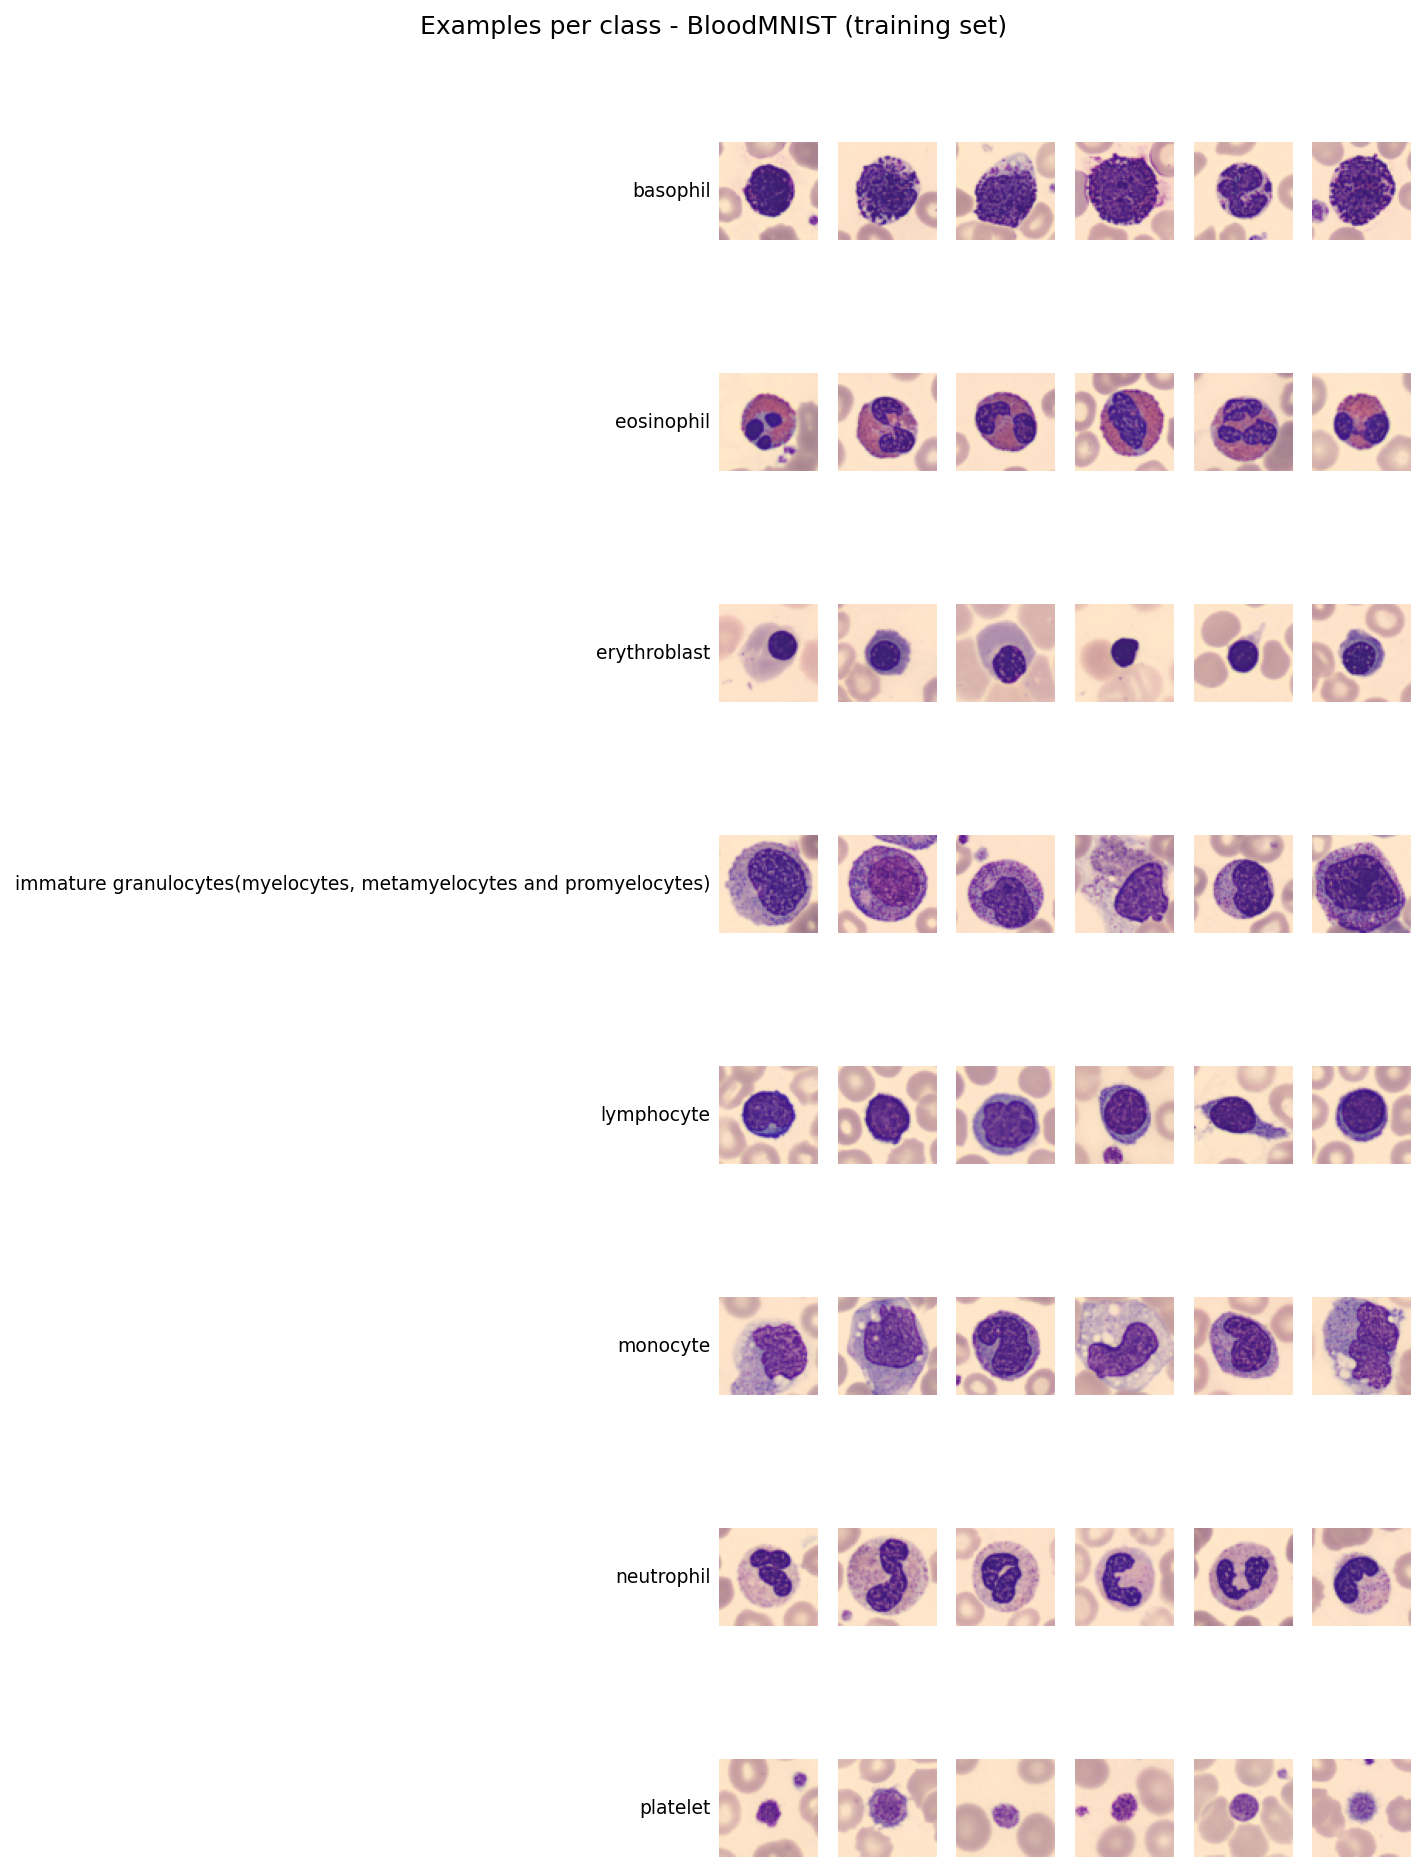

In [4]:
from IPython.display import Image, display
display(Image("/kaggle/working/eda/sample_grid.png"))


## 3. Three CNN architectures (TensorFlow)

Trains and evaluates the baseline CNN, the CNN + Squeeze-and-Excitation, and the patch-based fusion CNN, all in the same run.

**Results (first attempt):** Baseline 95.59%, SE-CNN 89.80% (unstable, superseded - see section 4), Patch fusion 96.20%.

Kaggle environment detected: True
Raw data (scratch):     /kaggle/temp/medmnist_data
Persistent output:      /kaggle/working
Classes (8): {'0': 'basophil', '1': 'eosinophil', '2': 'erythroblast', '3': 'immature granulocytes(myelocytes, metamyelocytes and promyelocytes)', '4': 'lymphocyte', '5': 'monocyte', '6': 'neutrophil', '7': 'platelet'}

>>> [Data download/loading] starting...
>>> [Data download/loading] completed in 0m 2.8s
Train shape: (11959, 64, 64, 3) (11959,)
Val shape:   (1712, 64, 64, 3) (1712,)
Test shape:  (3421, 64, 64, 3) (3421,)

>>> [Training baseline CNN] starting...


I0000 00:00:1789074864.287680      23 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1789074864.290658      23 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "baseline_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │         1,032 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 111,688 (436.28 KB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_2 (Sequential)       │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_5      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 8)              │         1,032 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 111,688 (436.28 KB)

 Trainable params: 111,240 (434.53 KB)

 Non-trainable params: 448 (1.75 KB)

Epoch 1/25
748/748 ━━━━━━━━━━━━━━━━━━━━ 12s 12ms/step - accuracy: 0.7640 - loss: 0.6812 - val_accuracy: 0.6412 - val_loss: 1.3215 - learning_rate: 0.0010
Epoch 2/25
748/748 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.8630 - loss: 0.4142 - val_accuracy: 0.8695 - val_loss: 0.3834 - learning_rate: 0.0010
Epoch 3/25
748/748 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - accuracy: 0.8843 - loss: 0.3497 - val_accuracy: 0.8107 - val_loss: 0.5673 - learning_rate: 0.0010
Epoch 4/25
748/748 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - accuracy: 0.8985 - loss: 0.3087 - val_accuracy: 0.8271 - val_loss: 0.5147 - learning_rate: 0.0010
Epoch 5/25
748/748 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - accuracy: 0.9068 - loss: 0.2853 - val_accuracy: 0.8746 - val_loss: 0.3607 - learning_rate: 0.0010
Epoch 6/25
748/748 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - accuracy: 0.9128 - loss: 0.2658 - val_accuracy: 0.8381 - val_loss: 0.5019 - learning_rate: 0.0010
Epoch 7/25
748/748 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - accuracy: 0.9164 - loss: 0

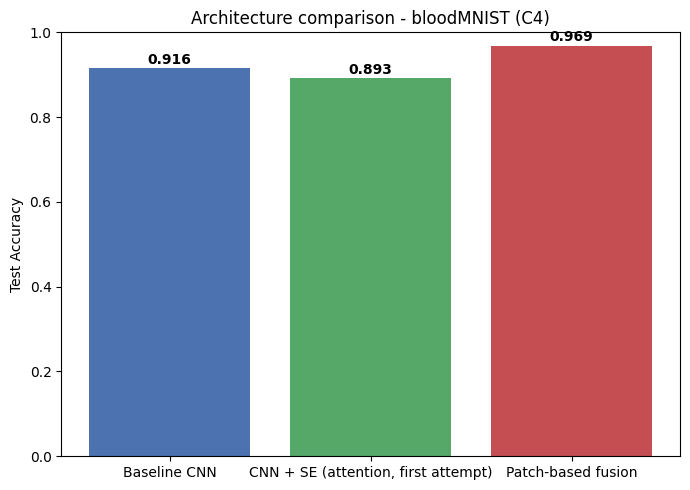


Comparison plot saved to '/kaggle/working/model_comparison.png'

=== Summary of files saved to /kaggle/working/ ===
- Model weights:      /kaggle/working/models/*.keras
- Training history:   /kaggle/working/reports/*_history.json
- Reports + matrices: /kaggle/working/reports/classification_reports.txt
- Accuracy summary:   /kaggle/working/reports/results_summary.json
- Phase timing log:   /kaggle/working/timing_log.txt
- Final plot:         /kaggle/working/model_comparison.png


In [5]:

# 0. Path setup: Kaggle vs local

ON_KAGGLE = os.environ.get("KAGGLE_KERNEL_RUN_TYPE") is not None
#  check if a Kaggle-only variable exists -> True if we are on Kaggle, False otherwise

if ON_KAGGLE:                                  # if we ARE on Kaggle...
    DATA_DIR = "/kaggle/temp/medmnist_data"    # ...raw data goes in this temporary folder
    OUTPUT_DIR = "/kaggle/working"             # ...results go in this permanent folder
else:                                          # if we are NOT on Kaggle (e.g. local computer)...
    DATA_DIR = "./medmnist_data"               # ... we use a local folder instead
    OUTPUT_DIR = "./output"                    # ...use a local folder instead

MODEL_DIR = os.path.join(OUTPUT_DIR, "models")     # build path: OUTPUT_DIR + "models"
REPORTS_DIR = os.path.join(OUTPUT_DIR, "reports")  # build path: OUTPUT_DIR + "reports"

for d in (DATA_DIR, MODEL_DIR, REPORTS_DIR):   # loop over these 3 folder paths, one by one
    os.makedirs(d, exist_ok=True)              # create the folder; do nothing if it already exists

print(f"Kaggle environment detected: {ON_KAGGLE}")   # show True/False on screen
print(f"Raw data (scratch):     {DATA_DIR}")         # show where raw data will go
print(f"Persistent output:      {OUTPUT_DIR}")       # show where results will go



@contextmanager   # this decorator turns the function below into a "with ... :" tool
def timer(phase_name, log_path=os.path.join(OUTPUT_DIR, "timing_log.txt")):
    start = time.time()                    # remember the current time (a number of seconds)
    print(f"\n>>> [{phase_name}] starting...") 
    yield                                   # <-- this is where the "with" block code actually runs
    elapsed = time.time() - start           # how many seconds passed since start
    minutes, seconds = divmod(elapsed, 60)  # split elapsed seconds into (minutes, remaining seconds)
    msg = f"[{phase_name}] completed in {int(minutes)}m {seconds:.1f}s"  # build a summary text
    print(f">>> {msg}")                     # show it on screen
    with open(log_path, "a") as f:          # open the log file in "append" mode ("a" = add to end)
        f.write(msg + "\n")                 # add this summary line to the file


# 1. Configuration and data loading

DATA_FLAG = "bloodmnist"  
IMAGE_SIZE = 64           
BATCH_SIZE = 64            
EPOCHS = 25                 

info = INFO[DATA_FLAG]                          # get bloodmnist's info dictionary
n_classes = len(info["label"])                  # count how many classes (8)
class_names = list(info["label"].values())      # get the class names as a plain list
print(f"Classes ({n_classes}): {info['label']}")  # show classes on screen

DataClass = getattr(medmnist, info["python_class"])
# ^ get the actual Python class (e.g. medmnist.BloodMNIST) using its name as text

with timer("Data download/loading"):    # everything indented below is timed as one phase
    train_dataset = DataClass(split="train", download=True, size=IMAGE_SIZE, root=DATA_DIR)
    # ^ create the training dataset object (downloads data if not already there)
    val_dataset   = DataClass(split="val",   download=True, size=IMAGE_SIZE, root=DATA_DIR)
    # ^ same, but for the validation split
    test_dataset  = DataClass(split="test",  download=True, size=IMAGE_SIZE, root=DATA_DIR)
    # ^ same, but for the test split

    def to_numpy(dataset):
        # small helper function: takes a medmnist dataset object, returns clean numpy arrays
        imgs = dataset.imgs.astype("float32") / 255.0
        # ^ get images, convert to decimal numbers, scale from 0-255 down to 0-1
        labels = dataset.labels.astype("int32").squeeze()
        # ^ get labels, convert to integers, remove the extra useless dimension
        return imgs, labels   # give back both results together

    X_train, y_train = to_numpy(train_dataset)   # run the helper on training data
    X_val,   y_val   = to_numpy(val_dataset)     # run the helper on validation data
    X_test,  y_test  = to_numpy(test_dataset)    # run the helper on test data

print("Train shape:", X_train.shape, y_train.shape)   # print the shape (dimensions) of train data
print("Val shape:  ", X_val.shape,   y_val.shape)      # print the shape of validation data
print("Test shape: ", X_test.shape,  y_test.shape)     # print the shape of test data

input_shape = X_train.shape[1:]
# ^ take the shape (N, 64, 64, 3) and drop the first number (N = image count) -> (64, 64, 3)


def make_data_augmentation():
    """Create a FRESH data augmentation block every time this is called.
    (See long explanation in the docstring - short version: don't reuse
    this object across models with different image sizes.)"""
    return models.Sequential([              # a small mini-model made of simple steps in order
        layers.RandomFlip("horizontal"),    # randomly mirror the image left-right sometimes
        layers.RandomRotation(0.1),         # randomly rotate the image a little sometimes
        layers.RandomZoom(0.1),             # randomly zoom in/out a little sometimes
    ])


def callbacks_factory(model_name):
    # "automatic"assistence that monitore the training phase 
    bestm_path = os.path.join(MODEL_DIR, f"{model_name}_best.keras")
    # ^ build the file path where the best version of this model will be saved
    return [
        tf.keras.callbacks.EarlyStopping(patience=6, restore_best_weights=True),
        # ^ stop training if no improvement for 6 epochs; keep the best weights seen
        tf.keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=3),
        # ^ if no improvement for 3 epochs, cut the learning rate in half
        tf.keras.callbacks.ModelCheckpoint(bestm_path, save_best_only=True, monitor="val_accuracy"),
        # ^ save the model to disk every time val_accuracy improves
    ]



# 2. Squeeze-and-Excitation block (channel attention)

def se_block(x, reduction=8):
    # x = the input tensor (feature map) coming from a conv layer
    # reduction = how much to shrink the "bottleneck" layer inside this block
    channels = x.shape[-1]                       # how many channels does x have (last dimension)
    s = layers.GlobalAveragePooling2D()(x)       # squash each channel down to one number
    s = layers.Dense(channels // reduction, activation="relu")(s)
    # ^ a small dense layer, output size = channels divided by reduction (integer division)
    s = layers.Dense(channels, activation="sigmoid")(s)
    # ^ another dense layer, back up to "channels" outputs, each between 0 and 1
    s = layers.Reshape((1, 1, channels))(s)     # reshape so it can multiply with x
    return layers.Multiply()([x, s])             # rescale x, channel by channel
# basically, this is the attention block that checks the channels and decides which ones are more important

# 3. Architectures

def conv_block(x, filters):
    # x = input tensor, filters = how many filters this conv layer should learn
    x = layers.Conv2D(filters, 3, padding="same", activation="relu")(x)
    # ^ a convolution layer: filters, 3x3 kernel, same size output, ReLU activation
    x = layers.BatchNormalization()(x)     # normalize the values, helps training be stable
    x = layers.MaxPooling2D()(x)           # shrink the image size by half (takes the max value)
    return x                               # give back the transformed tensor


def build_baseline_cnn(input_shape, n_classes, augment=True):
    # input_shape = e.g. (64,64,3); n_classes = 8; augment = whether to use data augmentation
    inputs = layers.Input(shape=input_shape)         # define the entry point of the model
    x = make_data_augmentation()(inputs) if augment else inputs
    # ^ if augment is True, pass inputs through augmentation; otherwise skip it

    x = conv_block(x, 32)     # first conv block, 32 filters
    x = conv_block(x, 64)     # second conv block, 64 filters
    x = conv_block(x, 128)    # third conv block, 128 filters

    x = layers.GlobalAveragePooling2D()(x)   # turn the whole feature map into one number per channel
    x = layers.Dense(128, activation="relu")(x)  # a normal fully-connected layer, 128 neurons
    x = layers.Dropout(0.4)(x)               # randomly "turn off" 40% of neurons during training
    outputs = layers.Dense(n_classes, activation="softmax")(x)
    # final layer: one output per class, softmax turns them into probabilities
    return models.Model(inputs, outputs, name="baseline_cnn")
    # package everything into a usable model object


def build_se_cnn(input_shape, n_classes, augment=True):
    """Same structure as the baseline, with an SE block after each conv block."""
    inputs = layers.Input(shape=input_shape)         # entry point of the model
    x = make_data_augmentation()(inputs) if augment else inputs   # optional augmentation

    for filters in [32, 64, 128]:     # loop over these 3 filter sizes, one block each
        x = layers.Conv2D(filters, 3, padding="same", activation="relu")(x)  # conv layer 3 x 3
        x = layers.BatchNormalization()(x)   # normalize
        x = se_block(x)                      # apply channel attention here
        x = layers.MaxPooling2D()(x)         # shrink image size by half

    x = layers.GlobalAveragePooling2D()(x)   # squash feature map to one number per channel
    x = layers.Dense(128, activation="relu")(x)  # fully-connected layer
    x = layers.Dropout(0.4)(x)               # randomly disable 40% of neurons
    outputs = layers.Dense(n_classes, activation="softmax")(x)  # final class probabilities
    return models.Model(inputs, outputs, name="se_cnn")  # package into a model object


def compile_model(model, lr=1e-3):
    # model = an uncompiled Keras model; lr = learning rate, default 0.001
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
        #  Adam = the algorithm that updates the model's weights during training
        loss="sparse_categorical_crossentropy",
        # the "error function" used for multi-class classification with integer labels
        metrics=["accuracy"],
        #  also track accuracy while training, just to watch it
    )
    return model     # give back the now-compiled model


def save_history(history, name):
    # history = the object returned by model.fit(); name = text label for the file name
    """Save the training history as JSON (see docstring above for why)."""
    hist_path = os.path.join(REPORTS_DIR, f"{name}_history.json")   # build the file path
    with open(hist_path, "w") as f:      # open the file for writing
        json.dump({k: [float(v) for v in vals] for k, vals in history.history.items()}, f, indent=2)
        #  convert the history data to plain numbers and save it as readable json text


# 4. Training: baseline and SE-CNN

with timer("Training baseline CNN"):    # time this whole block as one phase
    baseline_model = compile_model(build_baseline_cnn(input_shape, n_classes))
    # ^ build the baseline architecture, then compile it (set optimizer/loss)
    baseline_model.summary()            # print a text table describing the model's layers
    history_baseline = baseline_model.fit(
        X_train, y_train,                    # training data and labels
        validation_data=(X_val, y_val),      # data used to check progress each epoch
        batch_size=BATCH_SIZE, epochs=EPOCHS,  # how many images per step, max epochs
        callbacks=callbacks_factory("baseline_cnn"),  # early stopping, LR schedule, checkpoint
    )
    #  .fit() actually runs the training loop and returns a history of loss/accuracy
    save_history(history_baseline, "baseline_cnn")   # save that history to a json file
    baseline_model.save(os.path.join(MODEL_DIR, "baseline_cnn_final.keras"))
    #  save the fully trained model to a .keras file on disk

with timer("Training CNN + Squeeze-and-Excitation (first attempt, default hyperparameters)"):
    # by an improved version (se_cnn_v2) with better hyperparameters.
    se_model = compile_model(build_se_cnn(input_shape, n_classes))
    # build and compile the SE-CNN architecture
    se_model.summary()                   # print the model's layer table
    history_se = se_model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        batch_size=BATCH_SIZE, epochs=EPOCHS,
        callbacks=callbacks_factory("se_cnn"),
    )
    # run training for the SE-CNN model
    save_history(history_se, "se_cnn")   # save its training history to json
    se_model.save(os.path.join(MODEL_DIR, "se_cnn_final.keras"))   # save the trained model


# 5. Patch-based decision fusion


PATCH_SIZE = IMAGE_SIZE // 2   # half of 64 = 32 (integer division, "//" means no decimals)

def extract_patches(images):
    # images = a batch of images, shape (N, H, W, C)
    """
    Split a batch of images into 4 quadrants.
    """
    h, w = images.shape[1], images.shape[2]    # get height and width from the shape
    half_h, half_w = h // 2, w // 2            # find the midpoint of height and width

    patches = []                # empty list, will collect all the small patches
    for img in images:          # loop over every image in the batch, one at a time
        patches.append(img[0:half_h, 0:half_w, :])       # top-left quarter
        patches.append(img[0:half_h, half_w:w, :])       # top-right quarter
        patches.append(img[half_h:h, 0:half_w, :])       # bottom-left quarter
        patches.append(img[half_h:h, half_w:w, :])       # bottom-right quarter
    return np.stack(patches, axis=0)
    #  turn the list of small patches into one big numpy array


def expand_labels_for_patches(labels, n_patches=4):
    # labels = the original labels, one per full image
    return np.repeat(labels, n_patches)
    #  repeat each label 4 times in a row, so it matches the 4 patches from that image


with timer("Preparing patches for decision fusion"):
    X_train_patches = extract_patches(X_train)             # split all training images into patches
    y_train_patches = expand_labels_for_patches(y_train)    # repeat labels to match

    X_val_patches = extract_patches(X_val)                 # same for validation images
    y_val_patches = expand_labels_for_patches(y_val)        # same for validation labels

    print("Train patches shape:", X_train_patches.shape)   # show the new, bigger shape

patch_input_shape = (PATCH_SIZE, PATCH_SIZE, 3)   # the shape of a single patch: (32,32,3)

with timer("Training CNN on patches (decision fusion)"):
    patch_model = compile_model(build_baseline_cnn(patch_input_shape, n_classes))
    #reuse the SAME baseline architecture function, but with the smaller patch shape
    patch_model.summary()                # print the model's layer table
    history_patch = patch_model.fit(
        X_train_patches, y_train_patches,          # train on patches, not full images
        validation_data=(X_val_patches, y_val_patches),
        batch_size=BATCH_SIZE, epochs=EPOCHS,
        callbacks=callbacks_factory("patch_cnn"),
    )
    # ^ run training on the patch dataset
    save_history(history_patch, "patch_cnn")       # save training history
    patch_model.save(os.path.join(MODEL_DIR, "patch_cnn_final.keras"))   # save the trained model


def predict_with_patch_fusion(model, images):
    # model = the trained patch model; images = full-size images to classify
    """
    Predict on full images by averaging predictions over their 4 patches.
    """
    n = images.shape[0]                        # how many full images we have
    patches = extract_patches(images)          # split them all into patches (n*4 total)
    probs = model.predict(patches, verbose=0)  # get class probabilities for every patch
    probs = probs.reshape(n, 4, n_classes)     # reorganize: group each image's 4 patches together
    avg_probs = probs.mean(axis=1)             # average the 4 patch predictions per image
    return np.argmax(avg_probs, axis=1)
    # ^ pick the class with the highest averaged probability, for each image


# 6. Final evaluation and comparison on the test set

with timer("Final evaluation on the test set"):
    # --- Baseline CNN ---
    baseline_test_loss, baseline_test_acc = baseline_model.evaluate(X_test, y_test, verbose=0)
    # ^ run the trained baseline model on the test set, get loss and accuracy
    y_pred_baseline = np.argmax(baseline_model.predict(X_test, verbose=0), axis=1)
    #  get predicted probabilities, then pick the highest-probability class for each image

    # --- SE-CNN (first attempt) ---
    se_test_loss, se_test_acc = se_model.evaluate(X_test, y_test, verbose=0)
    # ^ same evaluation, but for the SE-CNN model
    y_pred_se = np.argmax(se_model.predict(X_test, verbose=0), axis=1)
    # ^ same prediction step, for the SE-CNN model

    # --- Patch fusion ---
    y_pred_patch = predict_with_patch_fusion(patch_model, X_test)
    # ^ use the special patch-fusion prediction function defined above
    patch_test_acc = np.mean(y_pred_patch == y_test)
    # ^ compare predictions to true labels (True/False for each), then average -> accuracy

    results = {
        "Baseline CNN": baseline_test_acc,                      # store each model's accuracy
        "CNN + SE (attention, first attempt)": se_test_acc,     # in one dictionary, for easy
        "Patch-based fusion": patch_test_acc,                   # comparison later
    }

    print("\n--- Test set accuracy summary ---")
    for name, acc in results.items():          # loop over the dictionary: name = key, acc = value
        print(f"{name:35s}: {acc:.4f}")        # print each model's name and accuracy, aligned

    # Detailed report for each model, both printed and saved to file
    report_txt_path = os.path.join(REPORTS_DIR, "classification_reports.txt")   # build file path
    with open(report_txt_path, "w") as f:      # open the report file for writing
        for name, y_pred in [                  # loop over 3 pairs: (model name, its predictions)
            ("Baseline CNN", y_pred_baseline),
            ("CNN + SE (attention, first attempt)", y_pred_se),
            ("Patch-based fusion", y_pred_patch),
        ]:
            report_str = classification_report(y_test, y_pred, target_names=class_names)
            #  compute precision/recall/F1 per class, as a formatted text block
            cm = confusion_matrix(y_test, y_pred)
            # compute the confusion matrix (which classes get mixed up with which)

            print(f"\n=== Classification report: {name} ===")   # print a header on screen
            print(report_str)                                    # print the report on screen

            f.write(f"=== Classification report: {name} ===\n")  # write the same header to file
            f.write(report_str + "\n")                            # write the report to file
            f.write("Confusion matrix:\n")                        # write a small header
            f.write(np.array2string(cm) + "\n\n")
            # ^ convert the confusion matrix array to readable text, write it to file

    # Accuracy summary also as JSON, handy for the final report
    with open(os.path.join(REPORTS_DIR, "results_summary.json"), "w") as f:  # open json file
        json.dump({k: float(v) for k, v in results.items()}, f, indent=2)
        #  save the results dictionary as json, converting numbers to plain floats first

    print(f"\nText reports saved to: {report_txt_path}")   # confirm on screen where it was saved


# 7. Comparison plot (accuracy per model)

plt.figure(figsize=(7, 5))              # start a new blank figure, 7x5 inches
names = list(results.keys())            # get just the model names from the dictionary
values = list(results.values())         # get just the accuracy numbers from the dictionary
colors = ["#4C72B0", "#55A868", "#C44E52"]   # 3 fixed colors, one per bar (hex color codes)
bars = plt.bar(names, values, color=colors)  # draw the bar chart, remember the bar objects
plt.ylabel("Test Accuracy")             # label for the vertical axis
plt.ylim(0, 1)                          # force the vertical axis to always go from 0 to 1
plt.title("Architecture comparison - bloodMNIST (C4)")   # chart title
for bar, v in zip(bars, values):        # loop over each bar together with its value, in pairs
    plt.text(bar.get_x() + bar.get_width() / 2, v + 0.01, f"{v:.3f}",
              ha="center", fontweight="bold")
    #  write the accuracy number just above each bar, centered horizontally
plt.tight_layout()                      # fix spacing so nothing gets cut off

plot_path = os.path.join(OUTPUT_DIR, "model_comparison.png")   # build the file path
plt.savefig(plot_path, dpi=150)         # save the chart as an image file
plt.show()                              # display the chart in the notebook
print(f"\nComparison plot saved to '{plot_path}'")   # confirm on screen

print("\n=== Summary of files saved to /kaggle/working/ ===")   # final recap header
print(f"- Model weights:      {MODEL_DIR}/*.keras")             # list what got saved, and where
print(f"- Training history:   {REPORTS_DIR}/*_history.json")
print(f"- Reports + matrices: {REPORTS_DIR}/classification_reports.txt")
print(f"- Accuracy summary:   {REPORTS_DIR}/results_summary.json")
print(f"- Phase timing log:   {OUTPUT_DIR}/timing_log.txt")
print(f"- Final plot:         {plot_path}")

## 4. SE-CNN retry: tuned hyperparameters

The first SE-CNN attempt trained unstably and was stopped early during an unstable phase (89.80% test accuracy).
I bring the learning rate 1e-3 to 5e-4 and raises the EarlyStopping patience (6 -> 10), giving the model more room to get past the unstable phase.

**Result: 96.76% test accuracy - the best of the three CNN architectures.** This is the model (`se_cnn_v2`) used in the final comparison and in the live demo.

In [6]:
"""
Extra experiment: retrain ONLY the CNN + Squeeze-and-Excitation
with more conservative hyperparameters, to check whether the low result
(89.8% test accuracy) from the first attempt was caused by unstable training
stopped too early, or by a limitation of the architecture.

What changes compared to the original script:
    - initial learning rate: 5e-4 instead of 1e-3 (lower -> smaller updates,
      less risk of the loss "spiking" during the first few epochs)
    - EarlyStopping patience: 10 instead of 6 (more room to get past an
      unstable phase before stopping and restoring not-yet-good weights)

As a result  this run produced the best of the three CNN architectures,
96.76% test accuracy (up from 89.80% in the first attempt). This is the
model used for the final comparison and for the live demo (se_cnn_v2).
"""


# 0. Path setup (identical to the main script)

ON_KAGGLE = os.environ.get("KAGGLE_KERNEL_RUN_TYPE") is not None
DATA_DIR = "/kaggle/temp/medmnist_data" if ON_KAGGLE else "./medmnist_data"
OUTPUT_DIR = "/kaggle/working" if ON_KAGGLE else "./output"
MODEL_DIR = os.path.join(OUTPUT_DIR, "models")
REPORTS_DIR = os.path.join(OUTPUT_DIR, "reports")
os.makedirs(DATA_DIR, exist_ok=True)
os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(REPORTS_DIR, exist_ok=True)

@contextmanager
def timer(phase_name):
    start = time.time()
    print(f"\n>>> [{phase_name}] starting...")
    yield
    elapsed = time.time() - start
    print(f">>> [{phase_name}] completed in {int(elapsed // 60)}m {elapsed % 60:.1f}s")



# 1. Data (reloaded from scratch: if it's already cached on disk this is
#    very fast; if X_train/y_train are already in memory in this session


DATA_FLAG = "bloodmnist"
IMAGE_SIZE = 64
BATCH_SIZE = 64

info = INFO[DATA_FLAG]
n_classes = len(info["label"])
class_names = list(info["label"].values())

DataClass = getattr(medmnist, info["python_class"])

with timer("Data loading"):
    train_dataset = DataClass(split="train", download=True, size=IMAGE_SIZE, root=DATA_DIR)
    val_dataset   = DataClass(split="val",   download=True, size=IMAGE_SIZE, root=DATA_DIR)
    test_dataset  = DataClass(split="test",  download=True, size=IMAGE_SIZE, root=DATA_DIR)

    def to_numpy(dataset):
        imgs = dataset.imgs.astype("float32") / 255.0
        labels = dataset.labels.astype("int32").squeeze()
        return imgs, labels

    X_train, y_train = to_numpy(train_dataset)
    X_val,   y_val   = to_numpy(val_dataset)
    X_test,  y_test  = to_numpy(test_dataset)

input_shape = X_train.shape[1:]



# 2. SE-CNN architecture (identical to the original, copied here to avoid
#    dependencies on other cells)

def make_data_augmentation():
    return models.Sequential([
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.1),
        layers.RandomZoom(0.1),
    ])


def se_block(x, reduction=8):
    channels = x.shape[-1]
    se = layers.GlobalAveragePooling2D()(x)
    se = layers.Dense(channels // reduction, activation="relu")(se)
    se = layers.Dense(channels, activation="sigmoid")(se)
    se = layers.Reshape((1, 1, channels))(se)
    return layers.Multiply()([x, se])


def build_se_cnn(input_shape, n_classes, augment=True):
    inputs = layers.Input(shape=input_shape)
    x = make_data_augmentation()(inputs) if augment else inputs

    for filters in [32, 64, 128]:
        x = layers.Conv2D(filters, 3, padding="same", activation="relu")(x)
        x = layers.BatchNormalization()(x)
        x = se_block(x)
        x = layers.MaxPooling2D()(x)

    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(128, activation="relu")(x)
    x = layers.Dropout(0.4)(x)
    outputs = layers.Dense(n_classes, activation="softmax")(x)
    return models.Model(inputs, outputs, name="se_cnn_v2")



# 3. Training with more conservative hyperparameters

LEARNING_RATE = 5e-4   # was 1e-3
EARLY_STOPPING_PATIENCE = 10  # was 6
EPOCHS = 35            # raised slightly to give the higher patience room to work

se_model_v2 = build_se_cnn(input_shape, n_classes)
se_model_v2.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)
se_model_v2.summary()

callbacks = [
    tf.keras.callbacks.EarlyStopping(patience=EARLY_STOPPING_PATIENCE, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=4),
    tf.keras.callbacks.ModelCheckpoint(
        os.path.join(MODEL_DIR, "se_cnn_v2_best.keras"), save_best_only=True, monitor="val_accuracy"
    ),
]

with timer("Training SE-CNN v2 (reduced learning rate, increased patience)"):
    history_se_v2 = se_model_v2.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        batch_size=BATCH_SIZE, epochs=EPOCHS,
        callbacks=callbacks,
    )

se_model_v2.save(os.path.join(MODEL_DIR, "se_cnn_v2_final.keras"))
with open(os.path.join(REPORTS_DIR, "se_cnn_v2_history.json"), "w") as f:
    json.dump({k: [float(v) for v in vals] for k, vals in history_se_v2.history.items()}, f, indent=2)


# 4. Evaluation and direct comparison with the original version

with timer("Evaluating SE-CNN v2 on the test set"):
    test_loss_v2, test_acc_v2 = se_model_v2.evaluate(X_test, y_test, verbose=0)
    y_pred_v2 = np.argmax(se_model_v2.predict(X_test, verbose=0), axis=1)

    print(f"\nSE-CNN v2 (lr={LEARNING_RATE}, patience={EARLY_STOPPING_PATIENCE}) - Test accuracy: {test_acc_v2:.4f}")
    print("For comparison, the first attempt (lr=1e-3, patience=6) achieved: 0.8980")

    report_str = classification_report(y_test, y_pred_v2, target_names=class_names)
    cm = confusion_matrix(y_test, y_pred_v2)

    print(f"\n=== Classification report: SE-CNN v2 ===")
    print(report_str)

    with open(os.path.join(REPORTS_DIR, "se_cnn_v2_report.txt"), "w") as f:
        f.write(f"SE-CNN v2 - Test accuracy: {test_acc_v2:.4f}\n")
        f.write(f"Comparison - SE-CNN v1 (original): 0.8980\n\n")
        f.write(report_str + "\n")
        f.write("Confusion matrix:\n")
        f.write(np.array2string(cm) + "\n")

print(f"\nFiles saved to: {REPORTS_DIR}/se_cnn_v2_report.txt and {MODEL_DIR}/se_cnn_v2_final.keras")



>>> [Data loading] starting...
>>> [Data loading] completed in 0m 2.7s


Model: "se_cnn_v2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_6       │ (None, 64, 64, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_3        │ (None, 64, 64, 3) │          0 │ input_layer_6[0]… │
│ (Sequential)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_9 (Conv2D)   │ (None, 64, 64,    │        896 │ sequential_3[0][… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        128 │ conv2d_9[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 32)        │          0 │ batch_normalizat… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_12 (Dense)    │ (None, 4)         │        132 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_13 (Dense)    │ (None, 32)        │        160 │ dense_12[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_3 (Reshape) │ (None, 1, 1, 32)  │          0 │ dense_13[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_3          │ (None, 64, 64,    │          0 │ batch_normalizat… │
│ (Multiply)          │ 32)               │            │ reshape_3[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_9     │ (None, 32, 32,    │          0 │ multiply_3[0][0]  │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_10 (Conv2D)  │ (None, 32, 32,    │     18,496 │ max_pooling2d_9[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        256 │ conv2d_10[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 64)        │          0 │ batch_normalizat… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_14 (Dense)    │ (None, 8)         │        520 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_15 (Dense)    │ (None, 64)        │        576 │ dense_14[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_4 (Reshape) │ (None, 1, 1, 64)  │          0 │ dense_15[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_4          │ (None, 32, 32,    │          0 │ batch_normalizat… │
│ (Multiply)          │ 64)               │            │ reshape_4[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_10    │ (None, 16, 16,    │          0 │ multiply_4[0][0]  │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_11 (Conv2D)  │ (None, 16, 16,    │     73,856 │ max_pooling2d_10

 Total params: 117,316 (458.27 KB)

 Trainable params: 116,868 (456.52 KB)

 Non-trainable params: 448 (1.75 KB)


>>> [Training SE-CNN v2 (reduced learning rate, increased patience)] starting...
Epoch 1/35
187/187 ━━━━━━━━━━━━━━━━━━━━ 11s 34ms/step - accuracy: 0.7353 - loss: 0.7994 - val_accuracy: 0.1373 - val_loss: 2.4166 - learning_rate: 5.0000e-04
Epoch 2/35
187/187 ━━━━━━━━━━━━━━━━━━━━ 6s 31ms/step - accuracy: 0.8905 - loss: 0.3298 - val_accuracy: 0.1460 - val_loss: 4.1023 - learning_rate: 5.0000e-04
Epoch 3/35
187/187 ━━━━━━━━━━━━━━━━━━━━ 6s 31ms/step - accuracy: 0.9238 - loss: 0.2290 - val_accuracy: 0.6676 - val_loss: 0.9496 - learning_rate: 5.0000e-04
Epoch 4/35
187/187 ━━━━━━━━━━━━━━━━━━━━ 6s 31ms/step - accuracy: 0.9387 - loss: 0.1897 - val_accuracy: 0.7231 - val_loss: 1.1981 - learning_rate: 5.0000e-04
Epoch 5/35
187/187 ━━━━━━━━━━━━━━━━━━━━ 6s 30ms/step - accuracy: 0.9455 - loss: 0.1598 - val_accuracy: 0.6974 - val_loss: 1.1116 - learning_rate: 5.0000e-04
Epoch 6/35
187/187 ━━━━━━━━━━━━━━━━━━━━ 6s 30ms/step - accuracy: 0.9495 - loss: 0.1493 - val_accuracy: 0.5689 - val_loss: 2.4679 - l

## 5. Fourth architecture: Spiking Neural Network (PyTorch)

The architecture is adapted directly from the course's SNN lab (a conv-SNN originally built for MNIST digit classification): two conv+pool+leaky-neuron blocks followed by a fully-connected leaky output layer, trained with rate coding (`snntorch.functional.ce_rate_loss`).

Two versions are trained and compared below:
- **28x28** (section 5.1): resolution matched to the original MNIST lab, so the architecture is changed as little as possible (only input channels and output classes).
- **64x64** (section 5.2): resolution matched to the other three architectures, for a fair final comparison - this required an extra debugging pass (see notes in that section).

In [7]:
!pip install -q medmnist snntorch

### 5.1 SNN at 28x28 (faithful to the course lab)

**Result: 63.20% test accuracy.**

In [8]:
"""
Fourth architecture: Spiking Neural Network (SNN), in PyTorch + snnTorch.

Architecture:  i adapted from the course's SNN lab (conv-SNN for MNIST
classification). To keep the adaptation as faithful as possible and reduce
the risk of bugs, BloodMNIST is downloaded at its native 28x28 resolution
(the same resolution used in the lab for MNIST), so the network stays
IDENTICAL to the lab version - only two numbers change:
    - input channels: 3 (RGB) instead of 1 (grayscale)
    - output classes: 8 instead of 10

RESULT: 63.20% test accuracy. 

"""


torch.manual_seed(100)


# 0. Path setup (same logic as the TensorFlow scripts, for consistency)

ON_KAGGLE = os.environ.get("KAGGLE_KERNEL_RUN_TYPE") is not None
DATA_DIR = "/kaggle/temp/medmnist_data" if ON_KAGGLE else "./medmnist_data"
OUTPUT_DIR = "/kaggle/working" if ON_KAGGLE else "./output"
MODEL_DIR = os.path.join(OUTPUT_DIR, "models")
REPORTS_DIR = os.path.join(OUTPUT_DIR, "reports")
for d in (DATA_DIR, MODEL_DIR, REPORTS_DIR):
    os.makedirs(d, exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")


@contextmanager
def timer(phase_name, log_path=os.path.join(OUTPUT_DIR, "timing_log.txt")):
    start = time.time()
    print(f"\n>>> [{phase_name}] starting...")
    yield
    elapsed = time.time() - start
    msg = f"[{phase_name}] completed in {int(elapsed // 60)}m {elapsed % 60:.1f}s"
    print(f">>> {msg}")
    with open(log_path, "a") as f:
        f.write(msg + "\n")



# 1. Data: BloodMNIST at 28x28, 
#    SNN lab for MNIST. Images stay RGB (3 channels).

DATA_FLAG = "bloodmnist"
IMAGE_SIZE = 28
BATCH_SIZE = 128  

info = INFO[DATA_FLAG]
n_classes = len(info["label"])
class_names = list(info["label"].values())

DataClass = getattr(medmnist, info["python_class"])

with timer("Data download/loading"):
    train_dataset_raw = DataClass(split="train", download=True, size=IMAGE_SIZE, root=DATA_DIR)
    val_dataset_raw   = DataClass(split="val",   download=True, size=IMAGE_SIZE, root=DATA_DIR)
    test_dataset_raw  = DataClass(split="test",  download=True, size=IMAGE_SIZE, root=DATA_DIR)


class BloodMNISTTorch(Dataset):
    """Minimal wrapper exposing MedMNIST images (numpy, 0-255) as normalized
    PyTorch tensors in [0, 1], in the (C, H, W) format expected by
    nn.Conv2d. Not using transforms.ToTensor() because the data is already
    numpy, no need to go through PIL."""

    def __init__(self, medmnist_dataset):
        self.imgs = medmnist_dataset.imgs.astype("float32") / 255.0  # (N, H, W, 3)
        self.labels = medmnist_dataset.labels.astype("int64").squeeze()  # (N,)

    def __len__(self):
        return len(self.imgs)

    def __getitem__(self, idx):
        img = torch.from_numpy(self.imgs[idx]).permute(2, 0, 1)  # (H,W,3) -> (3,H,W)
        label = int(self.labels[idx])
        return img, label


train_dataset = BloodMNISTTorch(train_dataset_raw)
val_dataset   = BloodMNISTTorch(val_dataset_raw)
test_dataset  = BloodMNISTTorch(test_dataset_raw)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, drop_last=False)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, drop_last=False)

print(f"Train: {len(train_dataset)} | Val: {len(val_dataset)} | Test: {len(test_dataset)}")


# 2. SNN architecture - IDENTICAL to the course lab, with only two changes:
#    the first conv's in_channels (3 instead of 1) and the number of output
#    classes (8 instead of 10). Same leaky neuron hyperparameters (beta=0.5),
#    same surrogate gradient (fast_sigmoid, slope=25), same number of
#    timesteps (25).

class SNN(nn.Module):
    def __init__(self, timesteps, n_classes):
        super().__init__()
        self.timesteps = timesteps

        # first layer: same structure as the lab, in_channels=3 (RGB)
        self.conv1 = nn.Conv2d(3, 12, 5)
        self.pool1 = nn.MaxPool2d(2)
        self.lif1 = snn.Leaky(beta=0.5, spike_grad=surrogate.fast_sigmoid(slope=25))

        # second layer: identical to the lab
        self.conv2 = nn.Conv2d(12, 32, 5)
        self.pool2 = nn.MaxPool2d(2)
        self.lif2 = snn.Leaky(beta=0.5, spike_grad=surrogate.fast_sigmoid(slope=25))

        # output layer: n_classes=8 instead of 10
        # With 28x28 input: conv1(k5)->24x24, pool->12x12, conv2(k5)->8x8, pool->4x4
        # so the flatten size stays 32*4*4=512, exactly like in the lab.
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(32 * 4 * 4, n_classes)
        self.lif3 = snn.Leaky(beta=0.5, spike_grad=surrogate.fast_sigmoid(slope=25), output=True)

    def forward(self, x):
        mem1 = self.lif1.init_leaky()
        mem2 = self.lif2.init_leaky()
        mem3 = self.lif3.init_leaky()

        spk_rec = []
        mem_rec = []

        for step in range(self.timesteps):
            cur1 = self.pool1(self.conv1(x))
            spk1, mem1 = self.lif1(cur1, mem1)

            cur2 = self.pool2(self.conv2(spk1))
            spk2, mem2 = self.lif2(cur2, mem2)

            cur3 = self.fc1(self.flatten(spk2))
            spk_out, mem_out = self.lif3(cur3, mem3)

            spk_rec.append(spk_out)
            mem_rec.append(mem_out)

        return torch.stack(spk_rec, dim=0), torch.stack(mem_rec, dim=0)


TIMESTEPS = 25  # same value used in the lab

classifier = SNN(timesteps=TIMESTEPS, n_classes=n_classes).to(device)
print(classifier)
n_params = sum(p.numel() for p in classifier.parameters() if p.requires_grad)
print(f"Trainable parameters: {n_params:,}")



# 3. Training - same function as the lab, with the addition of
#    history tracking to compare against the other architectures, plus
#    checkpointing of the best validation-accuracy weights (the lab only
#    kept the weights from the very last epoch, which is not necessarily
#    the best one)

def train_fn(model, train_loader, val_loader, accuracy, loss_fn, optimizer,
             epochs, test_every=50, verbose=True, checkpoint_path=None):
    N_train = len(train_loader)
    train_loss_list = []
    val_acc_list = []
    best_val_acc = -1.0

    model.train()
    counter = 0

    for epoch in range(epochs):
        start_time = time.time()
        train_loss = 0.0

        for X, y in tqdm.tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}"):
            X, y = X.to(device), y.to(device)

            spk_out, mem_out = model(X.float())

            optimizer.zero_grad()
            loss = loss_fn(spk_out, y)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()

            if counter % test_every == 0:
                with torch.no_grad():
                    model.eval()
                    total_acc = 0.0
                    for X_val, y_val in val_loader:
                        X_val, y_val = X_val.to(device), y_val.to(device)
                        spk_out_val, _ = model(X_val.float())
                        total_acc += accuracy(spk_out_val, y_val).item()
                    avg_val_acc = total_acc / len(val_loader)
                    val_acc_list.append(avg_val_acc)
                    if verbose:
                        print(f"  Iteration {counter}, Val Acc: {avg_val_acc * 100:.2f}%")

                    # Save the weights only if this is the best validation
                    # result seen so far. without this, I would end up with
                    # the weights from the last epoch, which isn't
                    # necessarily the best one.
                    if avg_val_acc > best_val_acc and checkpoint_path is not None:
                        best_val_acc = avg_val_acc
                        torch.save(model.state_dict(), checkpoint_path)

                    model.train()

            counter += 1

        train_loss_list.append(train_loss / N_train)
        torch.cuda.empty_cache()
        end_time = time.time()
        if verbose:
            print(f"Epoch {epoch+1}/{epochs} - {int(end_time - start_time)}s - "
                  f"loss: {round(train_loss_list[-1], 4)}")

    return train_loss_list, val_acc_list, best_val_acc


NUM_EPOCHS = 40  # training is very fast (~9s/epoch), so we can afford many
                  # more epochs (which used just 1, but
                  # on MNIST, an easier task)
CHECKPOINT_PATH = os.path.join(MODEL_DIR, "snn_best.pt")

optimizer = torch.optim.Adam(classifier.parameters(), lr=1e-2, betas=(0.9, 0.999))
loss_fn = SF.ce_rate_loss()
acc_fn = SF.acc.accuracy_rate

with timer(f"Training SNN ({NUM_EPOCHS} epochs)"):
    train_loss_list, val_acc_list, best_val_acc = train_fn(
        model=classifier,
        train_loader=train_loader,
        val_loader=val_loader,
        accuracy=acc_fn,
        loss_fn=loss_fn,
        optimizer=optimizer,
        epochs=NUM_EPOCHS,
        test_every=50,
        checkpoint_path=CHECKPOINT_PATH,
    )

print(f"\nBest validation accuracy during training: {best_val_acc * 100:.2f}%")

# Reload the best checkpoint's weights (not necessarily the last epoch's)
# before evaluating on the test set
classifier.load_state_dict(torch.load(CHECKPOINT_PATH, map_location=device))
torch.save(classifier.state_dict(), os.path.join(MODEL_DIR, "snn_final.pt"))
with open(os.path.join(REPORTS_DIR, "snn_history.json"), "w") as f:
    json.dump({"train_loss": train_loss_list, "val_acc": val_acc_list}, f, indent=2)


# 4. Final evaluation on the test set

with timer("Evaluating SNN on the test set"):
    classifier.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for X_test, y_test in test_loader:
            X_test = X_test.to(device)
            spk_out, _ = classifier(X_test.float())
            # sum of spikes over all timesteps for each class: the class
            # with the most total spikes is the model's prediction (same
            # rate-coding principle used by the training loss/accuracy)
            spike_counts = spk_out.sum(dim=0)  # (batch, n_classes)
            preds = torch.argmax(spike_counts, dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(y_test.numpy())

    test_acc = np.mean(np.array(all_preds) == np.array(all_labels))
    print(f"\nSNN - Test accuracy: {test_acc:.4f}")

    report_str = classification_report(all_labels, all_preds, target_names=class_names)
    cm = confusion_matrix(all_labels, all_preds)

    print(f"\n=== Classification report: SNN ===")
    print(report_str)

    with open(os.path.join(REPORTS_DIR, "snn_report.txt"), "w") as f:
        f.write(f"SNN - Test accuracy: {test_acc:.4f}\n")
        f.write(f"Trainable parameters: {n_params:,}\n")
        f.write(f"Input resolution: {IMAGE_SIZE}x{IMAGE_SIZE}x3, timesteps: {TIMESTEPS}\n\n")
        f.write(report_str + "\n")
        f.write("Confusion matrix:\n")
        f.write(np.array2string(cm) + "\n")

    results_summary_path = os.path.join(REPORTS_DIR, "results_summary.json")
    if os.path.exists(results_summary_path):
        with open(results_summary_path, "r") as f:
            try:
                results = json.load(f)
            except json.JSONDecodeError:
                results = {}
    else:
        results = {}
    results["SNN"] = float(test_acc)
    with open(results_summary_path, "w") as f:
        json.dump(results, f, indent=2)

print(f"\nFiles saved to: {REPORTS_DIR}/snn_report.txt and {MODEL_DIR}/snn_final.pt")


Device: cuda

>>> [Data download/loading] starting...


100%|██████████| 35.5M/35.5M [00:03<00:00, 9.70MB/s]


>>> [Data download/loading] completed in 0m 5.2s
Train: 11959 | Val: 1712 | Test: 3421
SNN(
  (conv1): Conv2d(3, 12, kernel_size=(5, 5), stride=(1, 1))
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (lif1): Leaky()
  (conv2): Conv2d(12, 32, kernel_size=(5, 5), stride=(1, 1))
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (lif2): Leaky()
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=512, out_features=8, bias=True)
  (lif3): Leaky()
)
Trainable parameters: 14,648

>>> [Training SNN (40 epochs)] starting...


Epoch 1/40:   3%|▎         | 3/93 [00:01<00:39,  2.30it/s]

  Iteration 0, Val Acc: 7.27%


...

Epoch 40/40:  82%|████████▏ | 76/93 [00:06<00:02,  7.32it/s]

  Iteration 3700, Val Acc: 63.43%


Epoch 40/40: 100%|██████████| 93/93 [00:08<00:00, 11.34it/s]


Epoch 40/40 - 8s - loss: 1.4662
>>> [Training SNN (40 epochs)] completed in 5m 20.0s

Best validation accuracy during training: 64.83%

>>> [Evaluating SNN on the test set] starting...

SNN - Test accuracy: 0.6445

=== Classification report: SNN ===
                                                                     precision    recall  f1-score   support

                                                           basophil       0.61      0.39      0.47       244
                                                         eosinophil       0.96      0.98      0.97       624
                                                       erythroblast       0.77      0.65      0.70       311
immature granulocytes(myelocytes, metamyelocytes and promyelocytes)       0.53      0.80      0.64       579
                                                         lymphocyte       0.70      0.71      0.70       243
                                                           monocyte       0.52      0.08      0

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


### 5.2 SNN at 64x64 (final, tuned)

**Debugging history** (kept here because it's directly relevant to the technical discussion in the report):
1. First attempt with the lab's original learning rate (1e-2): **total training collapse** - the model always predicted the same majority-ish class (19.47% test accuracy). Likely cause: the final layer is much larger at 64x64 (5,408 inputs vs. 512 at 28x28), so the same learning rate produces much larger, destabilizing weight updates.
2. Fix: learning rate lowered 10x (1e-2 -> 1e-3). A short 15-epoch diagnostic run confirmed smooth, stable convergence (66.06% test accuracy, still improving).
3. This script: full 40-epoch run with the corrected learning rate.

**Result: 86.64% test accuracy** - the best SNN result, and the one used in the four-way final comparison. Notably, the "platelet" class - which had 0% precision/recall at 28x28 (suspected resolution artifact, since platelets are the smallest cells in the dataset) - recovers to near-perfect precision/recall (0.99/0.99) here, confirming the resolution hypothesis.

In [9]:
"""

Fourth architecture: Spiking Neural Network (SNN), in PyTorch + snnTorch.

Compared to the 28x28 version, three numbers change
here instead of two:
    - input channels: 3 (RGB) instead of 1 (grayscale)
    - output classes: 8 instead of 10
    - flatten size after the two conv+pool blocks: with 64x64 input,
      conv1(k5)->60x60, pool->30x30, conv2(k5)->26x26, pool->13x13, so
      flatten = 32*13*13 = 5408 (instead of 32*4*4=512 at 28x28)


  1) First attempt at 64x64 with the lab's original learning rate (1e-2):
     total training collapse, the network settled into always predicting
     the same majority-ish class (19.47% test accuracy). Loss got stuck
     around 2.08 and never genuinely decreased. Diagnosis: the much larger
     final layer (5408 inputs vs 512) makes the same learning rate produce
     much larger, destabilizing weight updates.
  2) Fix: learning rate lowered from 1e-2 to 1e-3 (10x smaller). A short
     15-epoch diagnostic run confirmed smooth, stable convergence
     (66.06% test accuracy, still improving at the last epoch).
  3) This script: full 40-epoch run with the corrected learning rate.
     RESULT: 86.64% test accuracy - the best SNN result obtained, and the
     one used for the final comparison across all four architectures.
     Notably, "platelet" (which had 0% precision/recall at 28x28,
     suspected to be a resolution artifact) recovers to near-perfect
     precision/recall (0.99/0.99) at 64x64 with enough training, confirming
     that the earlier low-resolution collapse on that class was indeed a
     resolution effect and not an inherent architecture limitation.


"""



torch.manual_seed(100)


# 0. Path setup (same logic as the TensorFlow scripts, for consistency)

ON_KAGGLE = os.environ.get("KAGGLE_KERNEL_RUN_TYPE") is not None
DATA_DIR = "/kaggle/temp/medmnist_data" if ON_KAGGLE else "./medmnist_data"
OUTPUT_DIR = "/kaggle/working" if ON_KAGGLE else "./output"
MODEL_DIR = os.path.join(OUTPUT_DIR, "models")
REPORTS_DIR = os.path.join(OUTPUT_DIR, "reports")
for d in (DATA_DIR, MODEL_DIR, REPORTS_DIR):
    os.makedirs(d, exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")


@contextmanager
def timer(phase_name, log_path=os.path.join(OUTPUT_DIR, "timing_log.txt")):
    start = time.time()
    print(f"\n>>> [{phase_name}] starting...")
    yield
    elapsed = time.time() - start
    msg = f"[{phase_name}] completed in {int(elapsed // 60)}m {elapsed % 60:.1f}s"
    print(f">>> {msg}")
    with open(log_path, "a") as f:
        f.write(msg + "\n")


# 1. Data: BloodMNIST at 64x64, same resolution as the other three
#    architectures

DATA_FLAG = "bloodmnist"
IMAGE_SIZE = 64  # same resolution as the other three architectures
BATCH_SIZE = 128 

info = INFO[DATA_FLAG]
n_classes = len(info["label"])
class_names = list(info["label"].values())

DataClass = getattr(medmnist, info["python_class"])

with timer("Data download/loading"):
    train_dataset_raw = DataClass(split="train", download=True, size=IMAGE_SIZE, root=DATA_DIR)
    val_dataset_raw   = DataClass(split="val",   download=True, size=IMAGE_SIZE, root=DATA_DIR)
    test_dataset_raw  = DataClass(split="test",  download=True, size=IMAGE_SIZE, root=DATA_DIR)


class BloodMNISTTorch(Dataset):
    """Minimal wrapper exposing MedMNIST images (numpy, 0-255) as normalized
    PyTorch tensors in [0, 1], in the (C, H, W) format expected by
    nn.Conv2d. Not using transforms.ToTensor() because the data is already
    numpy, no need to go through PIL."""

    def __init__(self, medmnist_dataset):
        self.imgs = medmnist_dataset.imgs.astype("float32") / 255.0  # (N, H, W, 3)
        self.labels = medmnist_dataset.labels.astype("int64").squeeze()  # (N,)

    def __len__(self):
        return len(self.imgs)

    def __getitem__(self, idx):
        img = torch.from_numpy(self.imgs[idx]).permute(2, 0, 1)  # (H,W,3) -> (3,H,W)
        label = int(self.labels[idx])
        return img, label


train_dataset = BloodMNISTTorch(train_dataset_raw)
val_dataset   = BloodMNISTTorch(val_dataset_raw)
test_dataset  = BloodMNISTTorch(test_dataset_raw)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, drop_last=False)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, drop_last=False)

print(f"Train: {len(train_dataset)} | Val: {len(val_dataset)} | Test: {len(test_dataset)}")


# 2. SNN architecture - IDENTICAL to the course lab except for input
#    channels, output classes, and the flatten size (a consequence of the
#    larger input resolution)

class SNN(nn.Module):
    def __init__(self, timesteps, n_classes):
        super().__init__()
        self.timesteps = timesteps

        # first layer: same structure as the lab, in_channels=3 (RGB)
        self.conv1 = nn.Conv2d(3, 12, 5)
        self.pool1 = nn.MaxPool2d(2)
        self.lif1 = snn.Leaky(beta=0.5, spike_grad=surrogate.fast_sigmoid(slope=25))

        # second layer: identical to the lab
        self.conv2 = nn.Conv2d(12, 32, 5)
        self.pool2 = nn.MaxPool2d(2)
        self.lif2 = snn.Leaky(beta=0.5, spike_grad=surrogate.fast_sigmoid(slope=25))

        # output layer: n_classes=8 instead of 10
        # With 64x64 input: conv1(k5)->60x60, pool->30x30, conv2(k5)->26x26,
        # pool->13x13, so the flatten size is 32*13*13=5408 (much larger
        # than at 28x28 - this layer will have many more trainable
        # parameters).
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(32 * 13 * 13, n_classes)
        self.lif3 = snn.Leaky(beta=0.5, spike_grad=surrogate.fast_sigmoid(slope=25), output=True)

    def forward(self, x):
        mem1 = self.lif1.init_leaky()
        mem2 = self.lif2.init_leaky()
        mem3 = self.lif3.init_leaky()

        spk_rec = []
        mem_rec = []

        for step in range(self.timesteps):
            cur1 = self.pool1(self.conv1(x))
            spk1, mem1 = self.lif1(cur1, mem1)

            cur2 = self.pool2(self.conv2(spk1))
            spk2, mem2 = self.lif2(cur2, mem2)

            cur3 = self.fc1(self.flatten(spk2))
            spk_out, mem_out = self.lif3(cur3, mem3)

            spk_rec.append(spk_out)
            mem_rec.append(mem_out)

        return torch.stack(spk_rec, dim=0), torch.stack(mem_rec, dim=0)


TIMESTEPS = 25  # same value used in the lab

classifier = SNN(timesteps=TIMESTEPS, n_classes=n_classes).to(device)
print(classifier)
n_params = sum(p.numel() for p in classifier.parameters() if p.requires_grad)
print(f"Trainable parameters: {n_params:,}")



# 3. Training - same function as the lab (train_fn), with the addition of
#    history tracking and checkpointing of the best validation-accuracy
#    weights

def train_fn(model, train_loader, val_loader, accuracy, loss_fn, optimizer,
             epochs, test_every=50, verbose=True, checkpoint_path=None):
    N_train = len(train_loader)
    train_loss_list = []
    val_acc_list = []
    best_val_acc = -1.0

    model.train()
    counter = 0

    for epoch in range(epochs):
        start_time = time.time()
        train_loss = 0.0

        for X, y in tqdm.tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}"):
            X, y = X.to(device), y.to(device)

            spk_out, mem_out = model(X.float())

            optimizer.zero_grad()
            loss = loss_fn(spk_out, y)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()

            if counter % test_every == 0:
                with torch.no_grad():
                    model.eval()
                    total_acc = 0.0
                    for X_val, y_val in val_loader:
                        X_val, y_val = X_val.to(device), y_val.to(device)
                        spk_out_val, _ = model(X_val.float())
                        total_acc += accuracy(spk_out_val, y_val).item()
                    avg_val_acc = total_acc / len(val_loader)
                    val_acc_list.append(avg_val_acc)
                    if verbose:
                        print(f"  Iteration {counter}, Val Acc: {avg_val_acc * 100:.2f}%")

                 
                    if avg_val_acc > best_val_acc and checkpoint_path is not None:
                        best_val_acc = avg_val_acc
                        torch.save(model.state_dict(), checkpoint_path)

                    model.train()

            counter += 1

        train_loss_list.append(train_loss / N_train)
        torch.cuda.empty_cache()
        end_time = time.time()
        if verbose:
            print(f"Epoch {epoch+1}/{epochs} - {int(end_time - start_time)}s - "
                  f"loss: {round(train_loss_list[-1], 4)}")

    return train_loss_list, val_acc_list, best_val_acc


NUM_EPOCHS = 40  
CHECKPOINT_PATH = os.path.join(MODEL_DIR, "snn64_best.pt")

# Corrected learning rate (1e-3): with 1e-2 training collapsed completely
# (see the earlier attempt - the network collapsed into always predicting
# the same class). With 1e-3 training converges smoothly and stably.
optimizer = torch.optim.Adam(classifier.parameters(), lr=1e-3, betas=(0.9, 0.999))
loss_fn = SF.ce_rate_loss()
acc_fn = SF.acc.accuracy_rate

with timer(f"Training SNN ({NUM_EPOCHS} epochs)"):
    train_loss_list, val_acc_list, best_val_acc = train_fn(
        model=classifier,
        train_loader=train_loader,
        val_loader=val_loader,
        accuracy=acc_fn,
        loss_fn=loss_fn,
        optimizer=optimizer,
        epochs=NUM_EPOCHS,
        test_every=50,
        checkpoint_path=CHECKPOINT_PATH,
    )

print(f"\nBest validation accuracy during training: {best_val_acc * 100:.2f}%")

# Reload the best checkpoint's weights (not necessarily the last epoch's)
# before evaluating on the test set
classifier.load_state_dict(torch.load(CHECKPOINT_PATH, map_location=device))
torch.save(classifier.state_dict(), os.path.join(MODEL_DIR, "snn64_final.pt"))
with open(os.path.join(REPORTS_DIR, "snn64_history.json"), "w") as f:
    json.dump({"train_loss": train_loss_list, "val_acc": val_acc_list}, f, indent=2)


# 4. Final evaluation on the test set

with timer("Evaluating SNN on the test set"):
    classifier.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for X_test, y_test in test_loader:
            X_test = X_test.to(device)
            spk_out, _ = classifier(X_test.float())
            # sum of spikes over all timesteps for each class: the class
            # with the most total spikes is the model's prediction (same
            # rate-coding principle used by the training loss/accuracy)
            spike_counts = spk_out.sum(dim=0)  # (batch, n_classes)
            preds = torch.argmax(spike_counts, dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(y_test.numpy())

    test_acc = np.mean(np.array(all_preds) == np.array(all_labels))
    print(f"\nSNN - Test accuracy: {test_acc:.4f}")

    report_str = classification_report(all_labels, all_preds, target_names=class_names)
    cm = confusion_matrix(all_labels, all_preds)

    print(f"\n=== Classification report: SNN ===")
    print(report_str)

    with open(os.path.join(REPORTS_DIR, "snn64_report.txt"), "w") as f:
        f.write(f"SNN (64x64) - Test accuracy: {test_acc:.4f}\n")
        f.write(f"Comparison - SNN (28x28, faithful to the lab): 0.6320\n")
        f.write(f"Trainable parameters: {n_params:,}\n")
        f.write(f"Input resolution: {IMAGE_SIZE}x{IMAGE_SIZE}x3, timesteps: {TIMESTEPS}\n\n")
        f.write(report_str + "\n")
        f.write("Confusion matrix:\n")
        f.write(np.array2string(cm) + "\n")

    results_summary_path = os.path.join(REPORTS_DIR, "results_summary.json")
    if os.path.exists(results_summary_path):
        with open(results_summary_path, "r") as f:
            try:
                results = json.load(f)
            except json.JSONDecodeError:
                results = {}
    else:
        results = {}
    results["SNN_64x64"] = float(test_acc)
    with open(results_summary_path, "w") as f:
        json.dump(results, f, indent=2)

print(f"\nFiles saved to: {REPORTS_DIR}/snn64_report.txt and {MODEL_DIR}/snn64_final.pt")


Device: cuda

>>> [Data download/loading] starting...
>>> [Data download/loading] completed in 0m 2.3s
Train: 11959 | Val: 1712 | Test: 3421
SNN(
  (conv1): Conv2d(3, 12, kernel_size=(5, 5), stride=(1, 1))
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (lif1): Leaky()
  (conv2): Conv2d(12, 32, kernel_size=(5, 5), stride=(1, 1))
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (lif2): Leaky()
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=5408, out_features=8, bias=True)
  (lif3): Leaky()
)
Trainable parameters: 53,816

>>> [Training SNN (40 epochs)] starting...


Epoch 1/40:   2%|▏         | 2/93 [00:01<00:52,  1.74it/s]

  Iteration 0, Val Acc: 7.27%


Epoch 1/40:  56%|█████▌    | 52/93 [00:11<00:15,  2.65it/s]

  Iteration 50, Val Acc: 19.35%


...

  Iteration 3650, Val Acc: 87.37%


Epoch 40/40:  81%|████████  | 75/93 [00:16<00:06,  2.69it/s]

  Iteration 3700, Val Acc: 84.34%


Epoch 40/40: 100%|██████████| 93/93 [00:19<00:00,  4.75it/s]


Epoch 40/40 - 19s - loss: 1.3742
>>> [Training SNN (40 epochs)] completed in 13m 5.0s

Best validation accuracy during training: 87.37%

>>> [Evaluating SNN on the test set] starting...

SNN - Test accuracy: 0.8726

=== Classification report: SNN ===
                                                                     precision    recall  f1-score   support

                                                           basophil       0.85      0.80      0.83       244
                                                         eosinophil       0.97      0.99      0.98       624
                                                       erythroblast       0.88      0.87      0.88       311
immature granulocytes(myelocytes, metamyelocytes and promyelocytes)       0.65      0.84      0.73       579
                                                         lymphocyte       0.90      0.84      0.87       243
                                                           monocyte       0.82      0.34      

In [10]:
"""
Extra experiment: Center-crop CNN.

Motivation: the patch-based fusion architecture splits each image into 4
fixed quadrants, which means the cell (usually centered in the image, since
BloodMNIST itself was built via a center-crop of the original photos  see
the MedMNIST v2 paper) gets cut apart between patches. This script tests an
alternative: instead of cutting the image into 4 corner patches, crop a
single region around the CENTER of the image (where the cell actually is),
throwing away the empty background at the corners, and train the same
baseline CNN architecture on that.



"""



# 0. Path setup (identical to the other scripts)

ON_KAGGLE = os.environ.get("KAGGLE_KERNEL_RUN_TYPE") is not None
DATA_DIR = "/kaggle/temp/medmnist_data" if ON_KAGGLE else "./medmnist_data"
OUTPUT_DIR = "/kaggle/working" if ON_KAGGLE else "./output"
MODEL_DIR = os.path.join(OUTPUT_DIR, "models")
REPORTS_DIR = os.path.join(OUTPUT_DIR, "reports")
os.makedirs(DATA_DIR, exist_ok=True)
os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(REPORTS_DIR, exist_ok=True)


@contextmanager
def timer(phase_name):
    start = time.time()
    print(f"\n>>> [{phase_name}] starting...")
    yield
    elapsed = time.time() - start
    print(f">>> [{phase_name}] completed in {int(elapsed // 60)}m {elapsed % 60:.1f}s")


# 1. Data loading (same as the other scripts: normalized to 0-1)

DATA_FLAG = "bloodmnist"
IMAGE_SIZE = 64
BATCH_SIZE = 64
EPOCHS = 25

info = INFO[DATA_FLAG]
n_classes = len(info["label"])
class_names = list(info["label"].values())

DataClass = getattr(medmnist, info["python_class"])

with timer("Data loading"):
    train_dataset = DataClass(split="train", download=True, size=IMAGE_SIZE, root=DATA_DIR)
    val_dataset   = DataClass(split="val",   download=True, size=IMAGE_SIZE, root=DATA_DIR)
    test_dataset  = DataClass(split="test",  download=True, size=IMAGE_SIZE, root=DATA_DIR)

    def to_numpy(dataset):
        imgs = dataset.imgs.astype("float32") / 255.0
        labels = dataset.labels.astype("int32").squeeze()
        return imgs, labels

    X_train, y_train = to_numpy(train_dataset)
    X_val,   y_val   = to_numpy(val_dataset)
    X_test,  y_test  = to_numpy(test_dataset)



# 2. Center crop: keep only the middle 75% of each image (48x48 out of 64x64)

CROP_FRACTION = 0.75
CROP_SIZE = int(IMAGE_SIZE * CROP_FRACTION)  # 48 - divides by 2 three times, fits the
                                              # 3-block baseline architecture with no changes

def center_crop(images, crop_size):
    """Cut out a crop_size x crop_size square from the exact center of every
    image in the batch, discarding the outer border evenly on all sides."""
    h, w = images.shape[1], images.shape[2]
    start_h = (h - crop_size) // 2
    start_w = (w - crop_size) // 2
    return images[:, start_h:start_h + crop_size, start_w:start_w + crop_size, :]


with timer("Applying center crop"):
    X_train_crop = center_crop(X_train, CROP_SIZE)
    X_val_crop   = center_crop(X_val, CROP_SIZE)
    X_test_crop  = center_crop(X_test, CROP_SIZE)
    # labels are unchanged: cropping doesn't add or remove images, only
    # shrinks each one, so y_train/y_val/y_test stay exactly as they are

    print(f"Original shape:     {X_train.shape}")
    print(f"Center-cropped shape: {X_train_crop.shape}")

crop_input_shape = (CROP_SIZE, CROP_SIZE, 3)


# 3. Reuse the exact same baseline CNN architecture (self-contained copy)

def make_data_augmentation():
    return models.Sequential([
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.1),
        layers.RandomZoom(0.1),
    ])


def conv_block(x, filters):
    x = layers.Conv2D(filters, 3, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D()(x)
    return x


def build_baseline_cnn(input_shape, n_classes, augment=True):
    inputs = layers.Input(shape=input_shape)
    x = make_data_augmentation()(inputs) if augment else inputs

    x = conv_block(x, 32)
    x = conv_block(x, 64)
    x = conv_block(x, 128)

    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(128, activation="relu")(x)
    x = layers.Dropout(0.4)(x)
    outputs = layers.Dense(n_classes, activation="softmax")(x)
    return models.Model(inputs, outputs, name="center_crop_cnn")


def compile_model(model, lr=1e-3):
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model



# 4. Training - same hyperparameters as the original baseline (they were
#    already stable there, no reason to expect otherwise here)

crop_model = compile_model(build_baseline_cnn(crop_input_shape, n_classes))
crop_model.summary()

callbacks = [
    tf.keras.callbacks.EarlyStopping(patience=6, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=3),
    tf.keras.callbacks.ModelCheckpoint(
        os.path.join(MODEL_DIR, "center_crop_cnn_best.keras"), save_best_only=True, monitor="val_accuracy"
    ),
]

with timer("Training center-crop CNN"):
    history_crop = crop_model.fit(
        X_train_crop, y_train,
        validation_data=(X_val_crop, y_val),
        batch_size=BATCH_SIZE, epochs=EPOCHS,
        callbacks=callbacks,
    )

crop_model.save(os.path.join(MODEL_DIR, "center_crop_cnn_final.keras"))
with open(os.path.join(REPORTS_DIR, "center_crop_cnn_history.json"), "w") as f:
    json.dump({k: [float(v) for v in vals] for k, vals in history_crop.history.items()}, f, indent=2)



# 5. Evaluation and comparison against baseline / patch fusion

with timer("Evaluating center-crop CNN on the test set"):
    test_loss, test_acc = crop_model.evaluate(X_test_crop, y_test, verbose=0)
    y_pred = np.argmax(crop_model.predict(X_test_crop, verbose=0), axis=1)

    print(f"\nCenter-crop CNN (crop {CROP_FRACTION*100:.0f}%, {CROP_SIZE}x{CROP_SIZE}) - Test accuracy: {test_acc:.4f}")
    print("For comparison:")
    print("  Baseline CNN (full 64x64 image):      0.9559")
    print("  Patch-based fusion (4 corner patches): 0.9620")

    report_str = classification_report(y_test, y_pred, target_names=class_names)
    cm = confusion_matrix(y_test, y_pred)

    print(f"\n=== Classification report: Center-crop CNN ===")
    print(report_str)

    with open(os.path.join(REPORTS_DIR, "center_crop_report.txt"), "w") as f:
        f.write(f"Center-crop CNN (crop {CROP_FRACTION*100:.0f}%, {CROP_SIZE}x{CROP_SIZE}px) - Test accuracy: {test_acc:.4f}\n")
        f.write("Comparison - Baseline CNN (full image): 0.9559\n")
        f.write("Comparison - Patch-based fusion:        0.9620\n\n")
        f.write(report_str + "\n")
        f.write("Confusion matrix:\n")
        f.write(np.array2string(cm) + "\n")

    # add this result into the shared results_summary.json, if it exists
    results_summary_path = os.path.join(REPORTS_DIR, "results_summary.json")
    if os.path.exists(results_summary_path):
        with open(results_summary_path, "r") as f:
            try:
                results = json.load(f)
            except json.JSONDecodeError:
                results = {}
    else:
        results = {}
    results["Center-crop CNN"] = float(test_acc)
    with open(results_summary_path, "w") as f:
        json.dump(results, f, indent=2)

print(f"\nFiles saved to: {REPORTS_DIR}/center_crop_report.txt and {MODEL_DIR}/center_crop_cnn_final.keras")


>>> [Data loading] starting...
>>> [Data loading] completed in 0m 2.7s

>>> [Applying center crop] starting...
Original shape:     (11959, 64, 64, 3)
Center-cropped shape: (11959, 48, 48, 3)
>>> [Applying center crop] completed in 0m 0.0s


Model: "center_crop_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_8 (InputLayer)      │ (None, 48, 48, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_4 (Sequential)       │ (None, 48, 48, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 48, 48, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 48, 48, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 24, 24, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 24, 24, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 12, 12, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_10     │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 8)              │         1,032 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 111,688 (436.28 KB)

 Trainable params: 111,240 (434.53 KB)

 Non-trainable params: 448 (1.75 KB)


>>> [Training center-crop CNN] starting...
Epoch 1/25
187/187 ━━━━━━━━━━━━━━━━━━━━ 7s 19ms/step - accuracy: 0.8161 - loss: 0.5391 - val_accuracy: 0.1402 - val_loss: 4.9597 - learning_rate: 0.0010
Epoch 2/25
187/187 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.9013 - loss: 0.2837 - val_accuracy: 0.2541 - val_loss: 4.9665 - learning_rate: 0.0010
Epoch 3/25
187/187 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.9257 - loss: 0.2207 - val_accuracy: 0.7757 - val_loss: 0.7192 - learning_rate: 0.0010
Epoch 4/25
187/187 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.9371 - loss: 0.1804 - val_accuracy: 0.5771 - val_loss: 1.5142 - learning_rate: 0.0010
Epoch 5/25
187/187 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.9482 - loss: 0.1543 - val_accuracy: 0.7173 - val_loss: 1.0045 - learning_rate: 0.0010
Epoch 6/25
187/187 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.9543 - loss: 0.1350 - val_accuracy: 0.7880 - val_loss: 0.6668 - learning_rate: 0.0010
Epoch 7/25
187/187 ━━━━━━━━━━━━━━━━━━━

### Check saved model files
Quick sanity check before the live demo: confirms which model files are actually present in the current Kaggle session (`/kaggle/working/` is *not* persistent across sessions - if the kernel restarted, some files may be missing and need to be regenerated by re-running the relevant cell above).

In [11]:
!ls -la /kaggle/working/models/


total 14896
drwxr-xr-x 2 root root    4096 Sep 10 21:44 .
drwxr-xr-x 5 root root    4096 Sep 10 21:20 ..
-rw-r--r-- 1 root root 1416995 Sep 10 21:15 baseline_cnn_best.keras
-rw-r--r-- 1 root root 1416994 Sep 10 21:15 baseline_cnn_final.keras
-rw-r--r-- 1 root root 1417090 Sep 10 21:43 center_crop_cnn_best.keras
-rw-r--r-- 1 root root 1417090 Sep 10 21:44 center_crop_cnn_final.keras
-rw-r--r-- 1 root root 1417047 Sep 10 21:20 patch_cnn_best.keras
-rw-r--r-- 1 root root 1417047 Sep 10 21:20 patch_cnn_final.keras
-rw-r--r-- 1 root root 1538072 Sep 10 21:16 se_cnn_best.keras
-rw-r--r-- 1 root root 1538072 Sep 10 21:17 se_cnn_final.keras
-rw-r--r-- 1 root root 1538130 Sep 10 21:23 se_cnn_v2_best.keras
-rw-r--r-- 1 root root 1538131 Sep 10 21:24 se_cnn_v2_final.keras
-rw-r--r-- 1 root root  221685 Sep 10 21:42 snn64_best.pt
-rw-r--r-- 1 root root  221709 Sep 10 21:43 snn64_final.pt
-rw-r--r-- 1 root root   64965 Sep 10 21:26 snn_best.pt
-rw-r--r-- 1 root root   64989 Sep 10 21:29 snn_final.p

## 6. Live demo

Loads the three trained TensorFlow models (baseline, SE-CNN v2, patch fusion) and runs them live on one real test-set example per class, showing the true label alongside each model's prediction and confidence.

Meant to be re-run live during the oral exam - a fixed random seed keeps the same 8 examples every time, so you can rehearse in advance what to say about each one.

Loading models...
Models loaded:
  - Baseline CNN
  - SE-CNN (v2, tuned learning rate)
  - Patch-based fusion CNN
  - Center-crop CNN (extra experiment)

Running predictions...


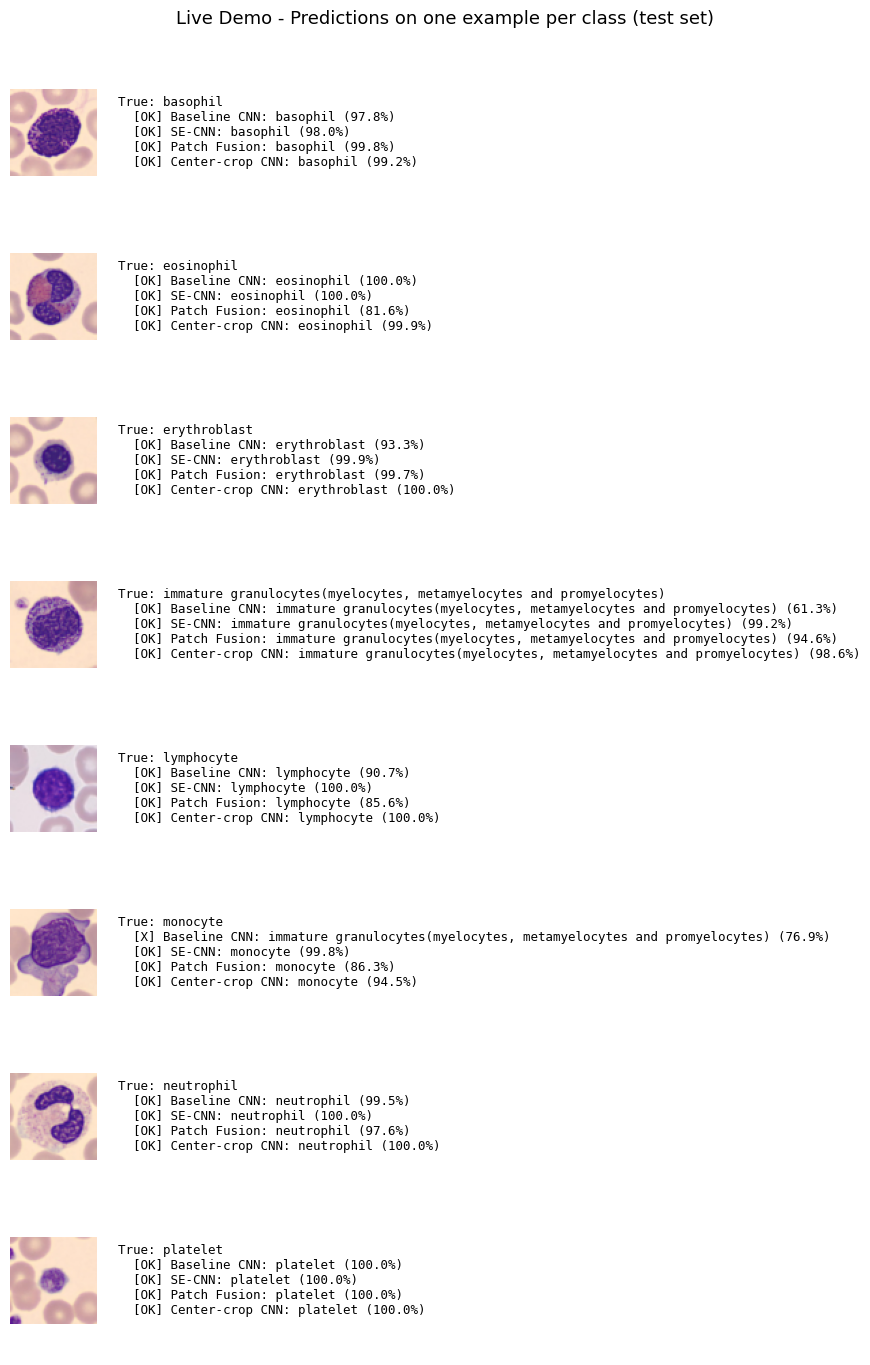


Demo saved to: /kaggle/working/live_demo.png

This same code can be re-run live during the exam:
it shows, live, that the models load and correctly predict on data never seen before.


In [12]:



# 0. Path setup (identical to the previous scripts)

ON_KAGGLE = os.environ.get("KAGGLE_KERNEL_RUN_TYPE") is not None
DATA_DIR = "/kaggle/temp/medmnist_data" if ON_KAGGLE else "./medmnist_data"
OUTPUT_DIR = "/kaggle/working" if ON_KAGGLE else "./output"
MODEL_DIR = os.path.join(OUTPUT_DIR, "models")


# 1. Load the test set (same 64x64 resolution used for the three CNNs)

DATA_FLAG = "bloodmnist"
IMAGE_SIZE = 64

info = INFO[DATA_FLAG]
n_classes = len(info["label"])
class_names = list(info["label"].values())

DataClass = getattr(medmnist, info["python_class"])
test_dataset = DataClass(split="test", download=True, size=IMAGE_SIZE, root=DATA_DIR)

X_test_raw = test_dataset.imgs  # uint8, 0-255 - kept as-is for display
y_test = test_dataset.labels.astype("int32").squeeze()
X_test_norm = X_test_raw.astype("float32") / 255.0  # normalized, for the models



# 2. Pick one example for each of the 8 classes (always the same ones, fixed seed)

rng = np.random.default_rng(42)
demo_indices = []
for class_idx in range(n_classes):
    class_positions = np.where(y_test == class_idx)[0]
    chosen = rng.choice(class_positions)
    demo_indices.append(chosen)

demo_images_raw = X_test_raw[demo_indices]
demo_images_norm = X_test_norm[demo_indices]
demo_labels = y_test[demo_indices]



# 3. Load the three already-trained TensorFlow models

print("Loading models...")

baseline_model = models.load_model(os.path.join(MODEL_DIR, "baseline_cnn_final.keras"))
se_model = models.load_model(os.path.join(MODEL_DIR, "se_cnn_v2_final.keras"))  # improved version
# Using the "best" checkpoint for patch fusion: this is the file saved
# during training every time validation accuracy improved, so it still
# contains the best observed weights, even if the "final" model (saved only
# at the very end of training) isn't available in this session.
patch_model = models.load_model(os.path.join(MODEL_DIR, "patch_cnn_best.keras"))
crop_model = models.load_model(os.path.join(MODEL_DIR, "center_crop_cnn_final.keras"))
# ^ the extra experiment: center-crop CNN, currently the second-best of all
# four CNN variants (96.70%), added here because it's a good story to walk
# through live - it came from noticing a design limitation in patch fusion

print("Models loaded:")
print(f"  - Baseline CNN")
print(f"  - SE-CNN (v2, tuned learning rate)")
print(f"  - Patch-based fusion CNN")
print(f"  - Center-crop CNN (extra experiment)")


# 4. Prediction functions (patch fusion needs the same patch-extraction
#    logic used during training 

def predict_simple(model, images):
    """Direct prediction: returns (predicted class, confidence of the predicted class)."""
    probs = model.predict(images, verbose=0)
    preds = np.argmax(probs, axis=1)
    confidences = np.max(probs, axis=1)
    return preds, confidences


def extract_patches(images):
    n = images.shape[0]
    h, w = images.shape[1], images.shape[2]
    half_h, half_w = h // 2, w // 2
    patches = []
    for img in images:
        patches.append(img[0:half_h, 0:half_w, :])
        patches.append(img[0:half_h, half_w:w, :])
        patches.append(img[half_h:h, 0:half_w, :])
        patches.append(img[half_h:h, half_w:w, :])
    return np.stack(patches, axis=0)


def predict_patch_fusion(model, images, n_classes):
    n = images.shape[0]
    patches = extract_patches(images)
    probs = model.predict(patches, verbose=0)
    probs = probs.reshape(n, 4, n_classes)
    avg_probs = probs.mean(axis=1)
    preds = np.argmax(avg_probs, axis=1)
    confidences = np.max(avg_probs, axis=1)
    return preds, confidences


def center_crop(images, crop_size):
    """Same center-crop logic used to train the crop_model: cut out a
    crop_size x crop_size square from the middle of every image."""
    h, w = images.shape[1], images.shape[2]
    start_h = (h - crop_size) // 2
    start_w = (w - crop_size) // 2
    return images[:, start_h:start_h + crop_size, start_w:start_w + crop_size, :]


# 5. Run live predictions on the 8 examples

print("\nRunning predictions...")

pred_baseline, conf_baseline = predict_simple(baseline_model, demo_images_norm)
pred_se, conf_se = predict_simple(se_model, demo_images_norm)
pred_patch, conf_patch = predict_patch_fusion(patch_model, demo_images_norm, n_classes)

CROP_SIZE = 48  # must match the crop size the center_crop_cnn was trained with
demo_images_crop = center_crop(demo_images_norm, CROP_SIZE)
pred_crop, conf_crop = predict_simple(crop_model, demo_images_crop)



# 6. Visualization: one row per example, with image + ground truth + the
#    three predictions (OK if correct, X if wrong)

fig, axes = plt.subplots(n_classes, 1, figsize=(9, n_classes * 1.7))

model_names = ["Baseline CNN", "SE-CNN", "Patch Fusion", "Center-crop CNN"]

for i in range(n_classes):
    ax = axes[i]
    true_label = class_names[demo_labels[i]]

    preds_this_row = [
        (model_names[0], class_names[pred_baseline[i]], conf_baseline[i], pred_baseline[i] == demo_labels[i]),
        (model_names[1], class_names[pred_se[i]], conf_se[i], pred_se[i] == demo_labels[i]),
        (model_names[2], class_names[pred_patch[i]], conf_patch[i], pred_patch[i] == demo_labels[i]),
        (model_names[3], class_names[pred_crop[i]], conf_crop[i], pred_crop[i] == demo_labels[i]),
    ]

    # image on the left
    img_ax = ax.inset_axes([0.0, 0.0, 0.12, 1.0])
    img_ax.imshow(demo_images_raw[i])
    img_ax.axis("off")

    # ground truth + predictions text on the right
    text_lines = [f"True: {true_label}"]
    for name, pred_label, conf, correct in preds_this_row:
        mark = "OK" if correct else "X"
        text_lines.append(f"  [{mark}] {name}: {pred_label} ({conf*100:.1f}%)")

    ax.text(0.15, 0.5, "\n".join(text_lines), fontsize=9, va="center", family="monospace",
            transform=ax.transAxes)
    ax.axis("off")

plt.suptitle("Live Demo - Predictions on one example per class (test set)", y=1.0, fontsize=13)
plt.tight_layout()

demo_output_path = os.path.join(OUTPUT_DIR, "live_demo.png")
plt.savefig(demo_output_path, dpi=150, bbox_inches="tight")
plt.show()

print(f"\nDemo saved to: {demo_output_path}")
print("\nThis same code can be re-run live during the exam:")
print("it shows, live, that the models load and correctly predict on data never seen before.")